# Final Project Notebook
---
# Analysis on Customer Churn and Product Churn in Online Grocery Platforms Using Behavioral Data

---
## Motivation

Online grocery platforms like Instacart operate at massive scale, serving millions of users and products. A key challenge in such systems is retention at both at the customer level and the product level.

From a business perspective, **losing a customer** leads to long-term revenue loss and losing product demand leads to inefficient inventory and missed sales opportunities. However, these problems are not independent. Customers often disengage gradually, and this behavior may be linked to changes in their purchasing patterns such as reduced order frequency or loss of frequently purchased products.

Despite the availability of large-scale transactional data, it remains difficult to:
- Identify which customers are likely to churn
- Detect which products are losing demand
- Understand the behavioral signals that precede churn

---
## Key Idea

Rather than treating customer churn and product churn as separate problems, we study how changes in purchasing behavior, both at the user level and product level that can be used to predict churn and guide actionable retention strategies.

---
## Project Objective

In this project, we aim to:

- Predict customer churn using behavioral features such as order frequency, recency, and reorder patterns
- Predict product churn by identifying products that are losing demand over time
- Analyze the relationship between customer behavior and product demand to uncover deeper insights

---
## Real-World Impact

The insights from this analysis can help online grocery platforms:

- Target high-risk customers with personalized retention strategies
- Identify declining products and take corrective actions (e.g., promotions or bundling)
- Improve recommendation systems and inventory planning

---
## Research Question
Everyone has the data on what the customer will buy next. But, can behavioral patterns in transaction data be used to predict both customer churn and product churn in an online grocery platform?

### Supporting Questions

To answer this, we explore the following:

1. Customer Churn Prediction
   - Which behavioral features (e.g., order frequency, recency, reorder rate) are most indicative of a customer becoming inactive?
   - How does the definition of churn impact prediction performance?
2. Product Churn Detection
   - Can we identify products that are losing demand using historical purchase patterns?
   - How do rule-based methods compare with machine learning approaches in detecting product churn?
3. Cross-Behavioral Insights
   - Is customer churn associated with changes in product interaction (e.g., loss of frequently reordered products)?
   - Are certain product categories (aisles or departments) more prone to churn?

We hypothesize that:
- Customers with declining engagement (lower frequency, lower reorder behavior, higher recency gaps) are more likely to churn
- Products with weak repeat purchase behavior are more likely to lose demand
- There is a strong relationship between product-level engagement and customer retention


---

## Dataset Description

This project uses the Instacart Market Basket Analysis dataset, which contains anonymized transaction-level data capturing how users purchase products over time.

In [42]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Download latest version
DATA_DIR = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", DATA_DIR)

Using Colab cache for faster access to the 'instacart-market-basket-analysis' dataset.
Path to dataset files: /kaggle/input/instacart-market-basket-analysis


In [43]:
# This function reduces RAM usage by converting large columns
# into smaller types wherever possible.
def reduce_memory(df):
    for col in df.columns:
        col_type = df[col].dtype

        # If the column is integer-like, downcast it to the smallest safe integer type
        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")

        # If the column is float-like, downcast it to the smallest safe float type
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")

    return df

# Load only the columns we actually need
# Orders table: customer ordering behavior over time
orders = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=[
        "order_id", "user_id", "eval_set", "order_number",
        "order_dow", "order_hour_of_day", "days_since_prior_order"
    ]
))

# Prior orders table: products purchased in historical orders
order_products_prior = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=["order_id", "product_id", "add_to_cart_order", "reordered"]
))

# Train orders table: loaded only for completeness / optional later use
order_products_train = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/order_products__train.csv"
))

# Product metadata
products = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "product_name", "aisle_id", "department_id"]
))

# Aisle metadata
aisles = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/aisles.csv",
    usecols=["aisle_id", "aisle"]
))

# Department metadata
departments = reduce_memory(pd.read_csv(
    f"{DATA_DIR}/departments.csv",
    usecols=["department_id", "department"]
))

# Print a compact summary instead of displaying full tables
print("Loaded all required tables successfully.\n")
print(f"orders shape: {orders.shape}")
print(f"order_products_prior shape: {order_products_prior.shape}")
print(f"order_products_train shape: {order_products_train.shape}")
print(f"products shape: {products.shape}")
print(f"aisles shape: {aisles.shape}")
print(f"departments shape: {departments.shape}")

Loaded all required tables successfully.

orders shape: (3421083, 7)
order_products_prior shape: (32434489, 4)
order_products_train shape: (1384617, 4)
products shape: (49688, 4)
aisles shape: (134, 2)
departments shape: (21, 2)


The full Instacart dataset is very large. To avoid memory issues in Colab, we work with a reproducible sample of users. This preserves the overall behavioral structure of the dataset while making joins and aggregations much more manageable.

In [44]:
# Sample a subset of users to reduce RAM usage
# We sample 50,000 unique users in a reproducible way.
# random_state=42 ensures the same sample every run.
sample_users = orders["user_id"].drop_duplicates().sample(50000, random_state=42)

# Keep only orders belonging to sampled users
orders_sample = orders[orders["user_id"].isin(sample_users)].copy()

# Keep only prior-order product rows that belong to the sampled users' orders
order_products_prior_sample = order_products_prior[
    order_products_prior["order_id"].isin(orders_sample["order_id"])
].copy()

print("Created sampled working dataset.\n")
print(f"Number of sampled users: {orders_sample['user_id'].nunique()}")
print(f"Sampled orders shape: {orders_sample.shape}")
print(f"Sampled prior order-product rows shape: {order_products_prior_sample.shape}")

Created sampled working dataset.

Number of sampled users: 50000
Sampled orders shape: (831128, 7)
Sampled prior order-product rows shape: (7927707, 4)


In [45]:
# Store all raw tables in a dictionary so we can summarize them easily
tables = {
    "orders": orders,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train,
    "products": products,
    "aisles": aisles,
    "departments": departments
}

# Build a small summary table showing number of rows and columns in each dataset
overview = pd.DataFrame({
    "table": list(tables.keys()),
    "rows": [df.shape[0] for df in tables.values()],
    "columns": [df.shape[1] for df in tables.values()]
})

print("Overview of raw Instacart tables:")
display(overview)
print("\nFinished dataset size overview.")

# Print only the first 3 rows of each table so the output stays compact
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print("-" * len(name))
    display(df.head(3))

print("\nFinished previewing all raw tables.")

Overview of raw Instacart tables:


,table,rows,columns
0,orders,3421083,7
1,order_products_prior,32434489,4
2,order_products_train,1384617,4
3,products,49688,4
4,aisles,134,2
5,departments,21,2



Finished dataset size overview.

ORDERS
------


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0



ORDER_PRODUCTS_PRIOR
--------------------


...


AISLES
------


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



DEPARTMENTS
-----------


,department_id,department
0,1,frozen
1,2,other
2,3,bakery



Finished previewing all raw tables.


The Instacart product table contains IDs for aisles and departments.
To make later analysis more interpretable, we attach the aisle and department names directly to each product.

In [46]:
# Merge product table with aisle and department metadata
# so each product has readable category information
products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

print("Created enriched product table.")
print(f"products_enriched shape: {products_enriched.shape}")
display(products_enriched.head(3))
print("\nFinished enriching product metadata.")

Created enriched product table.
products_enriched shape: (49688, 6)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages



Finished enriching product metadata.


In [47]:
# We use the SAMPLED tables here, not the full dataset,
# to keep RAM usage under control in Colab.

prior_data = (
    order_products_prior_sample
    .merge(
        orders_sample[
            ["order_id", "user_id", "order_number", "order_dow",
             "order_hour_of_day", "days_since_prior_order"]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        products_enriched[
            ["product_id", "product_name", "aisle_id", "department_id", "aisle", "department"]
        ],
        on="product_id",
        how="left"
    )
)

print("Built sampled merged transaction table successfully.")
print("Merged table validation summary:\n")
print(f"prior_data shape: {prior_data.shape}")
print("Unique users:", prior_data["user_id"].nunique())
print("Unique orders:", prior_data["order_id"].nunique())
print("Unique products:", prior_data["product_id"].nunique())
print("Unique aisles:", prior_data["aisle_id"].nunique())
print("Unique departments:", prior_data["department_id"].nunique())

print("\nPreview of merged transaction table:")
display(prior_data.head(3))
print("\nFinished validating merged transaction table.")

Built sampled merged transaction table successfully.
Merged table validation summary:

prior_data shape: (7927707, 14)
Unique users: 50000
Unique orders: 781128
Unique products: 46904
Unique aisles: 134
Unique departments: 21

Preview of merged transaction table:


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,6,40462,1,0,22352,4,1,12,30.0,Cleanse,31,7,refrigerated,beverages
1,6,15873,2,0,22352,4,1,12,30.0,Dryer Sheets Geranium Scent,75,17,laundry,household
2,6,41897,3,0,22352,4,1,12,30.0,Clean Day Lavender Scent Room Freshener Spray,101,17,air fresheners candles,household



Finished validating merged transaction table.


We now create the main working table for the analysis by joining:

- sampled prior-order product rows
- sampled order metadata
- enriched product metadata

This gives us one transaction-level table containing both customer behavior and product/category information.

In [48]:
# Base table for customer-level analysis
customer_base = prior_data[
    [
        "user_id", "order_id", "order_number", "order_dow",
        "order_hour_of_day", "days_since_prior_order",
        "product_id", "reordered", "add_to_cart_order"
    ]
].copy()

# Base table for product-level analysis
product_base = prior_data[
    [
        "product_id", "product_name", "aisle_id", "aisle",
        "department_id", "department", "user_id", "order_id",
        "order_number", "reordered", "days_since_prior_order"
    ]
].copy()

print("Created analysis-specific base tables.\n")
print(f"customer_base shape: {customer_base.shape}")
print(f"product_base shape: {product_base.shape}")

# Final compact summary of the sampled working dataset
summary = {
    "users": prior_data["user_id"].nunique(),
    "orders": prior_data["order_id"].nunique(),
    "products": prior_data["product_id"].nunique(),
    "aisles": prior_data["aisle"].nunique(),
    "departments": prior_data["department"].nunique()
}

summary_df = pd.DataFrame(summary, index=["count"]).T.rename(columns={"count": "value"})

print("Final sampled dataset summary:")
display(summary_df)
print("\nDataset setup complete.")

Created analysis-specific base tables.

customer_base shape: (7927707, 9)
product_base shape: (7927707, 11)
Final sampled dataset summary:


,value
users,50000
orders,781128
products,46904
aisles,134
departments,21



Dataset setup complete.


Due to the scale of the Instacart dataset and Colab memory limits, the analysis was conducted on a reproducible user-level sample. This preserves behavioral structure while enabling efficient experimentation and modeling.

---
## Part 1: Customer Churn



### Customer Churn Definition

To predict customer churn, the dataset does not explicitly provide churn labels, we define churn using behavioral signals derived from transaction history. The key idea is that customers who show **long inactivity gaps, weaker repeat behavior, or declining engagement** are more likely to churn.

To support this, we first construct a customer-level feature table capturing:
- ordering frequency
- basket behavior
- reorder patterns
- recent inactivity (recency)

========== DATA PREP ==========
Customer feature table built successfully.

========== THRESHOLD AND DATA PREP AGAIN ==========
Churn labels created successfully.

========== SUMMARY OF DATA PREP ==========
Customer feature table shape:


,Metric,Value
0,Rows,50000
1,Columns,26
2,Engineered Features Excluding user_id,25


Missing value check:


,Metric,Value
0,Numeric Missing Values Remaining,0


Recency summary:


...

Churn summary table:


,Sensitivity,Threshold_Days,Churned_Users,Active_Users,Churn_Rate
0,Low,30.0,12953,37047,25.906
1,Medium,19.0,20076,29924,40.152
2,High,12.0,28350,21650,56.700


Preview of final customer feature table:


,user_id,total_orders,total_items,unique_products,unique_aisles,unique_departments,avg_days_between_orders,max_days_between_orders,avg_order_hour,avg_order_dow,reorder_ratio,avg_basket_size,max_basket_size,avg_unique_products_per_order,avg_reordered_items_per_order,last_days_since_prior_order,avg_product_repeat_count,max_product_repeat_count,avg_product_reorders,items_per_order,product_diversity_ratio,aisle_diversity_ratio,department_diversity_ratio,churn_low,churn_medium,churn_high
0,5,4,37,23,16,9,14.500000,19.0,15.729730,1.621622,0.378378,9.250000,12,9.250000,3.500000,19.0,1.608696,4,0.608696,9.250000,0.621622,0.432432,0.243243,0,1,1
1,7,20,206,68,34,12,13.546391,30.0,13.631068,1.728155,0.669903,10.300000,24,10.300000,6.900000,7.0,3.029412,13,2.029412,10.300000,0.330097,0.165049,0.058252,0,0,0
2,12,5,74,61,33,14,26.169014,30.0,8.959459,3.108108,0.175676,14.800000,22,14.800000,2.600000,30.0,1.213115,3,0.213115,14.800000,0.824324,0.445946,0.189189,1,1,1
3,13,12,81,29,17,11,7.381579,13.0,15.135802,3.098765,0.641975,6.750000,10,6.750000,4.333333,6.0,2.793103,12,1.793103,6.750000,0.358025,0.209877,0.135802,0,0,0
4,21,33,205,102,38,12,10.055000,30.0,10.814634,2.029268,0.502439,6.212121,17,6.212121,3.121212,30.0,2.009804,21,1.009804,6.212121,0.497561,0.185366,0.058537,1,1,1


========== VISUALIZE ==========


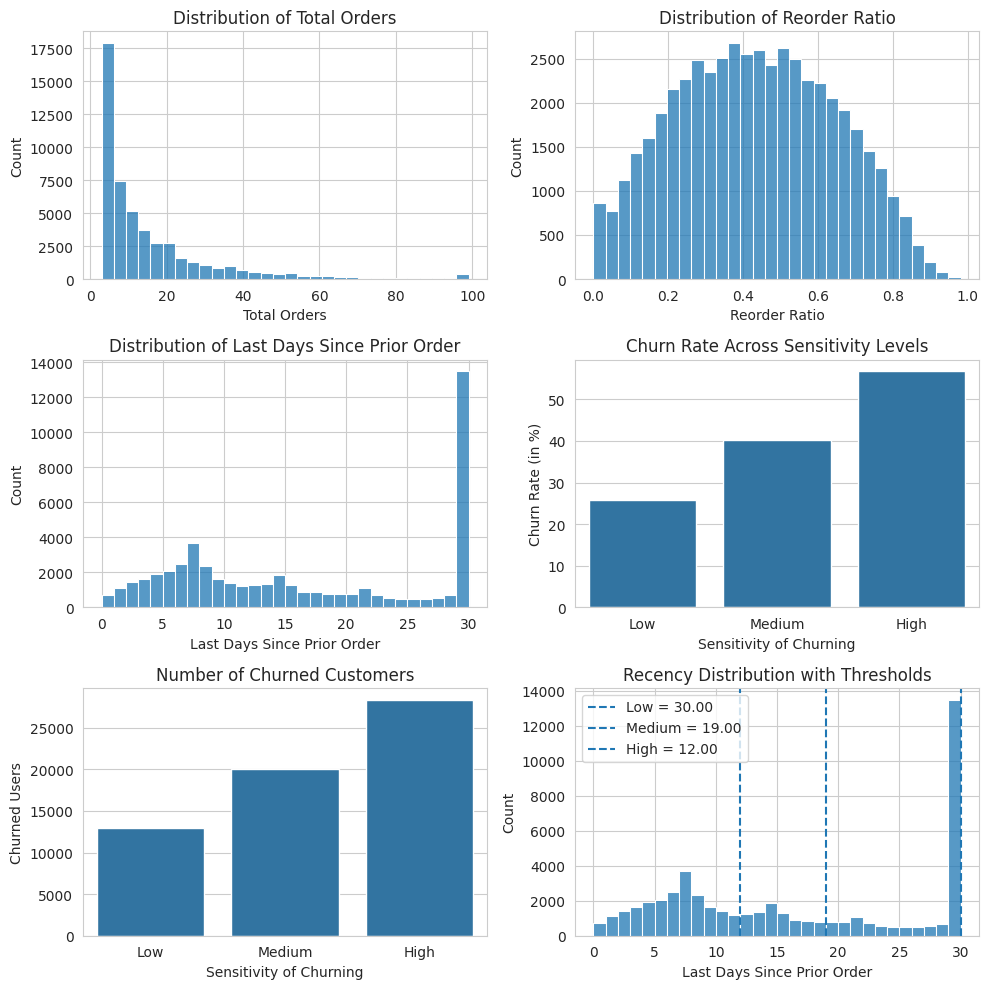

In [49]:
# ============================================================
# CUSTOMER CHURN - DATA PREP, THRESHOLDS, SUMMARY, VISUALIZE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("========== DATA PREP ==========")

# Build order-level basket features
# This summarizes each order into basket size, reordered items, and product variety.
order_basket = (
    prior_data.groupby(["user_id", "order_id"], as_index=False)
    .agg(
        basket_size=("product_id", "count"),
        reordered_items=("reordered", "sum"),
        unique_products_in_order=("product_id", "nunique")
    )
)

# Build base customer-level behavior features
# This captures customer frequency, engagement, diversity, and reorder behavior.
customer_features = (
    prior_data.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_items=("product_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_aisles=("aisle_id", "nunique"),
        unique_departments=("department_id", "nunique"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        max_days_between_orders=("days_since_prior_order", "max"),
        avg_order_hour=("order_hour_of_day", "mean"),
        avg_order_dow=("order_dow", "mean"),
        reorder_ratio=("reordered", "mean")
    )
    .reset_index()
)

# Build customer basket behavior features
# This adds basket-level patterns like average size and repeated items per order.
basket_features = (
    order_basket.groupby("user_id", as_index=False)
    .agg(
        avg_basket_size=("basket_size", "mean"),
        max_basket_size=("basket_size", "max"),
        avg_unique_products_per_order=("unique_products_in_order", "mean"),
        avg_reordered_items_per_order=("reordered_items", "mean")
    )
)

# Merge basket features into the main customer table
# This keeps all customer behavior signals in one place.
customer_features = customer_features.merge(
    basket_features,
    on="user_id",
    how="left"
)

# Add recency proxy from the latest observed order
# This acts as a recent inactivity signal for churn labeling.
last_order_gap = (
    prior_data.sort_values(["user_id", "order_number"])
    .groupby("user_id", as_index=False)
    .tail(1)[["user_id", "days_since_prior_order"]]
    .rename(columns={"days_since_prior_order": "last_days_since_prior_order"})
)

customer_features = customer_features.merge(
    last_order_gap,
    on="user_id",
    how="left"
)

# Count how often each customer bought each product
# This helps measure repeat buying and product dependence.
user_product_counts = (
    prior_data.groupby(["user_id", "product_id"], as_index=False)
    .agg(
        times_purchased=("order_id", "count"),
        times_reordered=("reordered", "sum")
    )
)

# Build loyalty features at customer level
# These summarize how strongly users repeat the same products.
loyalty_features = (
    user_product_counts.groupby("user_id", as_index=False)
    .agg(
        avg_product_repeat_count=("times_purchased", "mean"),
        max_product_repeat_count=("times_purchased", "max"),
        avg_product_reorders=("times_reordered", "mean")
    )
)

# Merge loyalty features into the customer table
# This adds repeat-purchase behavior to the final feature set.
customer_features = customer_features.merge(
    loyalty_features,
    on="user_id",
    how="left"
)

# Create ratio-based features
# These make customer behavior easier to compare across different activity levels.
customer_features["items_per_order"] = customer_features["total_items"] / customer_features["total_orders"]
customer_features["product_diversity_ratio"] = customer_features["unique_products"] / customer_features["total_items"]
customer_features["aisle_diversity_ratio"] = customer_features["unique_aisles"] / customer_features["total_items"]
customer_features["department_diversity_ratio"] = customer_features["unique_departments"] / customer_features["total_items"]

# Clean missing and infinite values
# This makes the feature table safe for summaries, plots, and modeling.
customer_features = customer_features.replace([np.inf, -np.inf], np.nan)
numeric_cols = customer_features.select_dtypes(include=[np.number]).columns
customer_features[numeric_cols] = customer_features[numeric_cols].fillna(0)

print("Customer feature table built successfully.\n")

print("========== THRESHOLD AND DATA PREP AGAIN ==========")

# Summarize the recency proxy
# This shows how recent inactivity is distributed across customers.
recency_summary = customer_features["last_days_since_prior_order"].describe().to_frame("Value")

# Define churn thresholds using data-driven percentiles
# Low is strict, medium is balanced, and high is earlier warning.
low_threshold = customer_features["last_days_since_prior_order"].quantile(0.75)
medium_threshold = customer_features["last_days_since_prior_order"].quantile(0.60)
high_threshold = customer_features["last_days_since_prior_order"].quantile(0.45)

# Store thresholds in a table
# This makes the churn definitions easy to read and compare.
threshold_df = pd.DataFrame({
    "Sensitivity": ["Low", "Medium", "High"],
    "Threshold_Days": [low_threshold, medium_threshold, high_threshold]
})

# Create churn labels for all three sensitivity levels
# A customer is labeled churned if recency is at or above the chosen threshold.
customer_features["churn_low"] = (customer_features["last_days_since_prior_order"] >= low_threshold).astype(int)
customer_features["churn_medium"] = (customer_features["last_days_since_prior_order"] >= medium_threshold).astype(int)
customer_features["churn_high"] = (customer_features["last_days_since_prior_order"] >= high_threshold).astype(int)

print("Churn labels created successfully.\n")

print("========== SUMMARY OF DATA PREP ==========")

# Count missing values after cleaning
# This confirms the feature table is complete.
missing_check = pd.DataFrame({
    "Metric": ["Numeric Missing Values Remaining"],
    "Value": [customer_features[numeric_cols].isnull().sum().sum()]
})

# Summarize churn counts and rates
# This shows how many users are churned under each threshold setting.
churn_summary_df = pd.DataFrame({
    "Sensitivity": ["Low", "Medium", "High"],
    "Threshold_Days": [low_threshold, medium_threshold, high_threshold],
    "Churned_Users": [
        customer_features["churn_low"].sum(),
        customer_features["churn_medium"].sum(),
        customer_features["churn_high"].sum()
    ],
    "Active_Users": [
        len(customer_features) - customer_features["churn_low"].sum(),
        len(customer_features) - customer_features["churn_medium"].sum(),
        len(customer_features) - customer_features["churn_high"].sum()
    ],
    "Churn_Rate": [
        customer_features["churn_low"].mean()*100,
        customer_features["churn_medium"].mean()*100,
        customer_features["churn_high"].mean()*100
    ]
})

# Show the overall feature table shape
# This tells us how many customers and columns were engineered.
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Engineered Features Excluding user_id"],
    "Value": [
        customer_features.shape[0],
        customer_features.shape[1],
        customer_features.shape[1] - 1
    ]
})

print("Customer feature table shape:")
display(shape_df)

print("Missing value check:")
display(missing_check)

print("Recency summary:")
display(recency_summary)

print("Threshold table:")
display(threshold_df)

print("Churn summary table:")
display(churn_summary_df)

print("Preview of final customer feature table:")
display(customer_features.head())

print("========== VISUALIZE ==========")

# Build helper tables for plotting
# These make churn plots cleaner and easier to read.
churn_rates = churn_summary_df[["Sensitivity", "Churn_Rate"]].copy()
churn_counts = churn_summary_df[["Sensitivity", "Churned_Users"]].copy()

# Create 6 summary plots in a 3x2 layout
# These visuals explain the full section without reading the code.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

# Plot 1: Total orders distribution
# This shows how active customers are overall.
sns.histplot(customer_features["total_orders"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Total Orders")
axes[0].set_xlabel("Total Orders")
axes[0].set_ylabel("Count")

# Plot 2: Reorder ratio distribution
# This shows how strongly customers repeat previous purchases.
sns.histplot(customer_features["reorder_ratio"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Reorder Ratio")
axes[1].set_xlabel("Reorder Ratio")
axes[1].set_ylabel("Count")

# Plot 3: Recency proxy distribution
# This shows recent inactivity, which is used to define churn.
sns.histplot(customer_features["last_days_since_prior_order"], bins=30, ax=axes[2])
axes[2].set_title("Distribution of Last Days Since Prior Order")
axes[2].set_xlabel("Last Days Since Prior Order")
axes[2].set_ylabel("Count")

# Plot 4: Churn rate across sensitivities
# This shows how churn increases as the threshold becomes more sensitive.
sns.barplot(data=churn_rates, x="Sensitivity", y="Churn_Rate", ax=axes[3])
axes[3].set_title("Churn Rate Across Sensitivity Levels")
axes[3].set_xlabel("Sensitivity of Churning")
axes[3].set_ylabel("Churn Rate (in %)")

# Plot 5: Number of churned customers
# This shows the class balance under each churn definition.
sns.barplot(data=churn_counts, x="Sensitivity", y="Churned_Users", ax=axes[4])
axes[4].set_title("Number of Churned Customers")
axes[4].set_xlabel("Sensitivity of Churning")
axes[4].set_ylabel("Churned Users")

# Plot 6: Recency with threshold lines
# This shows exactly where the three churn cutoffs fall on the recency distribution.
sns.histplot(customer_features["last_days_since_prior_order"], bins=30, ax=axes[5])
axes[5].axvline(low_threshold, linestyle="--", label=f"Low = {low_threshold:.2f}")
axes[5].axvline(medium_threshold, linestyle="--", label=f"Medium = {medium_threshold:.2f}")
axes[5].axvline(high_threshold, linestyle="--", label=f"High = {high_threshold:.2f}")
axes[5].set_title("Recency Distribution with Thresholds")
axes[5].set_xlabel("Last Days Since Prior Order")
axes[5].set_ylabel("Count")
axes[5].legend()

plt.tight_layout()
plt.show()

### Customer Churn Sensitivity

========== EXAMINE MULTIPLE DISTRIBUTIONS ==========
========== SUMMARIZE ==========
Low sensitivity summary:


last_days_since_prior_order        reorder_ratio         \
                                 mean median          mean median   
churn_low                                                           
0                              11.232    9.0         0.464  0.468   
1                              30.000   30.0         0.342  0.333   

          avg_basket_size        items_per_order         \
                     mean median            mean median   
churn_low                                                 
0                  10.130  9.133          10.130  9.133   
1                   9.539  8.533           9.539  8.533   

          avg_product_repeat_count        product_diversity_ratio         
                              mean median                    mean median  
churn_low                                                                 
0                            2.331  1.881                   0.536  0.532  
1                            1.696  1.500                   0.658  0.667

Medium sensitivity summary:


last_days_since_prior_order        reorder_ratio         \
                                    mean median          mean median   
churn_medium                                                           
0                               8.320000    7.0         0.477  0.488   
1                              27.681999   30.0         0.364  0.355   

             avg_basket_size        items_per_order         \
                        mean median            mean median   
churn_medium                                                 
0                     10.124  9.167          10.124  9.167   
1                      9.758  8.667           9.758  8.667   

             avg_product_repeat_count        product_diversity_ratio         
                                 mean median                    mean median  
churn_medium                                                                 
0                               2.425  1.952                   0.523  0.512  
1                               1.782  1.550                   0.636  0.645

High sensitivity summary:


last_days_since_prior_order        reorder_ratio         \
                                  mean median          mean median   
churn_high                                                           
0                                5.927    6.0         0.490  0.504   
1                               23.858   27.0         0.388  0.381   

           avg_basket_size        items_per_order         \
                      mean median            mean median   
churn_high                                                 
0                   10.035  9.052          10.035  9.052   
1                    9.932  8.909           9.932  8.909   

           avg_product_repeat_count        product_diversity_ratio         
                               mean median                    mean median  
churn_high                                                                 
0                             2.537  2.015                   0.510  0.496  
1                             1.885  1.615                   0.612  0.619

Combined comparison table:


,Sensitivity,Group,last_days_since_prior_order,reorder_ratio,avg_basket_size,items_per_order,avg_product_repeat_count,product_diversity_ratio
0,Low,Active,11.232000,0.464,10.130,10.130,2.331,0.536
1,Low,Churned,30.000000,0.342,9.539,9.539,1.696,0.658
2,Medium,Active,8.320000,0.477,10.124,10.124,2.425,0.523
3,Medium,Churned,27.681999,0.364,9.758,9.758,1.782,0.636
4,High,Active,5.927000,0.490,10.035,10.035,2.537,0.510
5,High,Churned,23.858000,0.388,9.932,9.932,1.885,0.612


========== VISUALIZE ==========


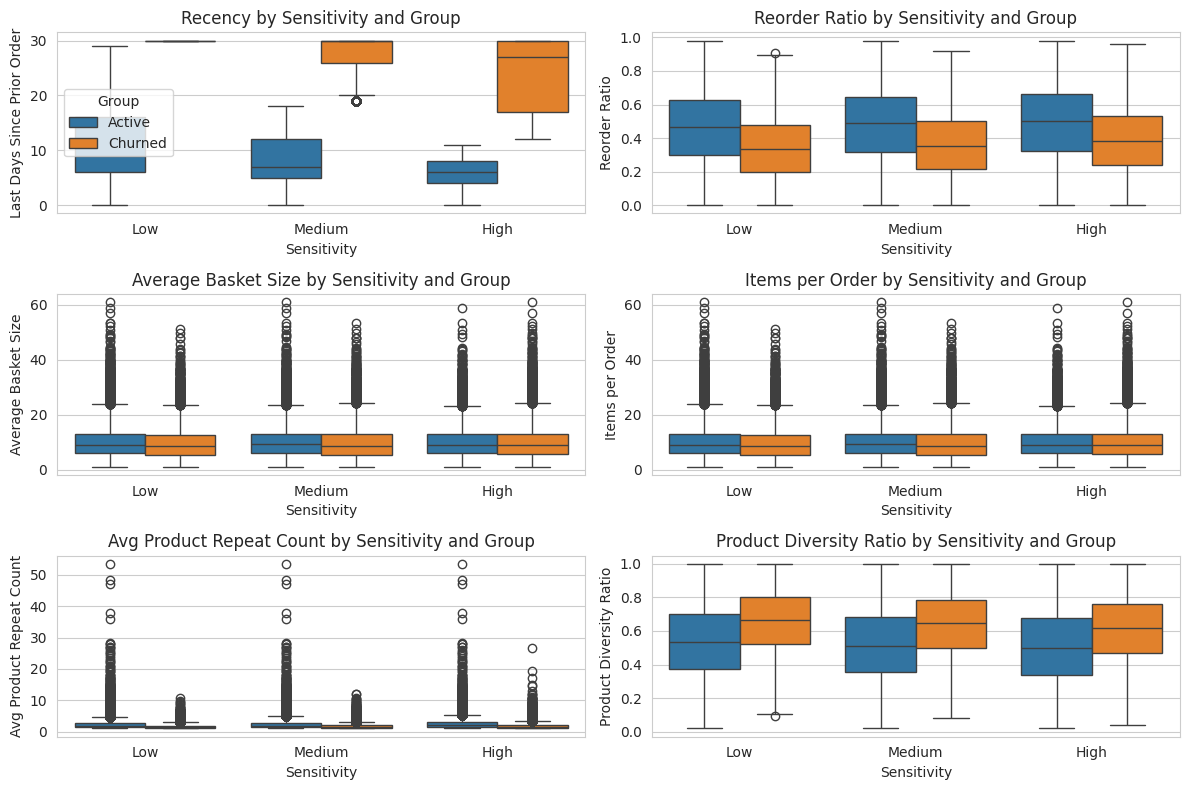

In [50]:
# ============================================================
# CUSTOMER CHURN - EXAMINE DISTRIBUTIONS, SUMMARY, VISUALIZE
# ============================================================

print("========== EXAMINE MULTIPLE DISTRIBUTIONS ==========")

# Choose the main behavior features to compare
# These are the key signals linked to customer churn.
compare_cols = [
    "last_days_since_prior_order",
    "reorder_ratio",
    "avg_basket_size",
    "items_per_order",
    "avg_product_repeat_count",
    "product_diversity_ratio"
]

# Build grouped summaries for each churn sensitivity
# This compares churned and active customers under each threshold setting.
summary_low = (
    customer_features.groupby("churn_low")[compare_cols]
    .agg(["mean", "median"])
    .round(3)
)
summary_medium = (
    customer_features.groupby("churn_medium")[compare_cols]
    .agg(["mean", "median"])
    .round(3)
)
summary_high = (
    customer_features.groupby("churn_high")[compare_cols]
    .agg(["mean", "median"])
    .round(3)
)

# Build a compact average comparison table
# This gives one clean results table across all sensitivities.
def build_comparison_table(label_col, sensitivity_name):
    temp = (
        customer_features.groupby(label_col)[compare_cols]
        .mean()
        .reset_index()
        .rename(columns={label_col: "Group"})
    )
    temp["Group"] = temp["Group"].map({0: "Active", 1: "Churned"})
    temp["Sensitivity"] = sensitivity_name
    return temp

comparison_table = pd.concat([
    build_comparison_table("churn_low", "Low"),
    build_comparison_table("churn_medium", "Medium"),
    build_comparison_table("churn_high", "High")
], ignore_index=True)

comparison_table = comparison_table[
    ["Sensitivity", "Group"] + compare_cols
].round(3)

print("========== SUMMARIZE ==========")

print("Low sensitivity summary:")
display(summary_low)

print("Medium sensitivity summary:")
display(summary_medium)

print("High sensitivity summary:")
display(summary_high)

print("Combined comparison table:")
display(comparison_table)

print("========== VISUALIZE ==========")

# Reshape data for multi-threshold comparison plots
# This helps compare active vs churned groups side by side.
plot_frames = []
for label_col, label_name in [("churn_low", "Low"), ("churn_medium", "Medium"), ("churn_high", "High")]:
    temp = customer_features[[label_col] + compare_cols].copy()
    temp["Sensitivity"] = label_name
    temp["Group"] = temp[label_col].map({0: "Active", 1: "Churned"})
    plot_frames.append(temp.drop(columns=[label_col]))

plot_df = pd.concat(plot_frames, ignore_index=True)

# Create 6 comparison plots in a 3x2 layout
# These show how churned and active customers differ across sensitivities.
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot 1: Recency comparison
# Churned customers should show larger inactivity gaps.
sns.boxplot(data=plot_df, x="Sensitivity", y="last_days_since_prior_order", hue="Group", ax=axes[0])
axes[0].set_title("Recency by Sensitivity and Group")
axes[0].set_xlabel("Sensitivity")
axes[0].set_ylabel("Last Days Since Prior Order")

# Plot 2: Reorder ratio comparison
# This shows whether churned customers reorder less often.
sns.boxplot(data=plot_df, x="Sensitivity", y="reorder_ratio", hue="Group", ax=axes[1])
axes[1].set_title("Reorder Ratio by Sensitivity and Group")
axes[1].set_xlabel("Sensitivity")
axes[1].set_ylabel("Reorder Ratio")

# Plot 3: Average basket size comparison
# This checks whether churned users tend to buy smaller baskets.
sns.boxplot(data=plot_df, x="Sensitivity", y="avg_basket_size", hue="Group", ax=axes[2])
axes[2].set_title("Average Basket Size by Sensitivity and Group")
axes[2].set_xlabel("Sensitivity")
axes[2].set_ylabel("Average Basket Size")

# Plot 4: Items per order comparison
# This shows whether churned users purchase fewer items per order.
sns.boxplot(data=plot_df, x="Sensitivity", y="items_per_order", hue="Group", ax=axes[3])
axes[3].set_title("Items per Order by Sensitivity and Group")
axes[3].set_xlabel("Sensitivity")
axes[3].set_ylabel("Items per Order")

# Plot 5: Product repeat count comparison
# This shows whether churned users are less loyal to repeated products.
sns.boxplot(data=plot_df, x="Sensitivity", y="avg_product_repeat_count", hue="Group", ax=axes[4])
axes[4].set_title("Avg Product Repeat Count by Sensitivity and Group")
axes[4].set_xlabel("Sensitivity")
axes[4].set_ylabel("Avg Product Repeat Count")

# Plot 6: Product diversity comparison
# This shows whether churned users buy with narrower or broader variety.
sns.boxplot(data=plot_df, x="Sensitivity", y="product_diversity_ratio", hue="Group", ax=axes[5])
axes[5].set_title("Product Diversity Ratio by Sensitivity and Group")
axes[5].set_xlabel("Sensitivity")
axes[5].set_ylabel("Product Diversity Ratio")

# Keep legends neat
# This removes repeated legend clutter from every subplot.
for i, ax in enumerate(axes):
    if i != 0:
        ax.get_legend().remove()

axes[0].legend(title="Group")

plt.tight_layout()
plt.show()

We construct a customer-level feature table capturing behavioral signals such as order frequency, recency, reorder behavior, basket size, and product loyalty. Since churn is not explicitly labeled, we define it using recency (inactivity) with three sensitivity thresholds: 30 days (low), 19 days (medium), and 12 days (high). This results in churn rates of 25.9%, 40.1%, and 56.7% respectively, allowing us to analyze churn under both strict and early-warning scenarios. The recency distribution (mean ≈ 16 days, median = 14 days) and strong separation between active and churned users confirm that inactivity is a reliable and interpretable proxy for churn.

Behavioral analysis shows clear and consistent patterns across all thresholds. Churned users exhibit significantly higher inactivity (e.g., \~30 vs \~11 days at low sensitivity), lower reorder ratios (\~0.34 vs \~0.46), and reduced product loyalty (repeat count \~1.7 vs \~2.3). At the same time, they show higher product diversity (\~0.65 vs \~0.53), indicating weaker attachment to specific products and more exploratory behavior before disengagement. Basket size and order volume show minimal differences, suggesting that engagement quality. Recency, consistency, and loyalty is far more predictive than sheer activity. These findings validate our hypothesis and establish a strong behavioral foundation for linking customer churn with product-level dynamics in the next stage.

### Customer Churn Modelling

========== CUSTOMER CHURN MODELLING - DATA PREP AND PROCESSING ==========
Number of model features: 21
Preview of selected model features:


,Feature
0,total_orders
1,total_items
2,unique_products
3,unique_aisles
4,unique_departments
5,avg_days_between_orders
6,max_days_between_orders
7,avg_order_hour
8,avg_order_dow
9,reorder_ratio


========== RANDOM FOREST MODEL ==========
Random Forest models trained for Low, Medium, and High sensitivity.

Model performance summary:


,Accuracy,Precision,Recall,F1,ROC_AUC
Low,0.8032,0.6926,0.4323,0.5323,0.8644
Medium,0.7579,0.7194,0.6508,0.6834,0.8481
High,0.7514,0.7537,0.8340,0.7919,0.8306


========== SUMMARIZE FEATURE IMPORTANCE LIST ==========
Top feature importance list:


...

========== IDENTIFY HIGH RISK CUSTOMERS ==========
High-risk customer summary:


,Metric,Value
0,Risk Score Cutoff (Top 20%),0.6576
1,High Risk Customer Count,10000.0000
2,Observed Medium Churn Rate in High Risk Group,0.8866


Top high-risk customers:


,user_id,churn_risk_score,churn_medium,total_orders,reorder_ratio,avg_basket_size
312,1262,0.974041,1,3,0.250000,1.333333
28378,117277,0.973625,1,3,0.250000,1.333333
23255,96199,0.973487,1,3,0.250000,1.333333
24568,101654,0.972856,1,3,0.500000,1.333333
25517,105593,0.972723,1,3,0.250000,1.333333
43048,177547,0.972561,1,3,0.250000,1.333333
48534,199947,0.972311,1,3,0.250000,1.333333
426,1728,0.972280,1,3,0.250000,1.333333
21094,87442,0.971918,1,3,0.250000,1.333333
44178,182195,0.971673,1,3,0.250000,1.333333


========== VISUALIZE ==========


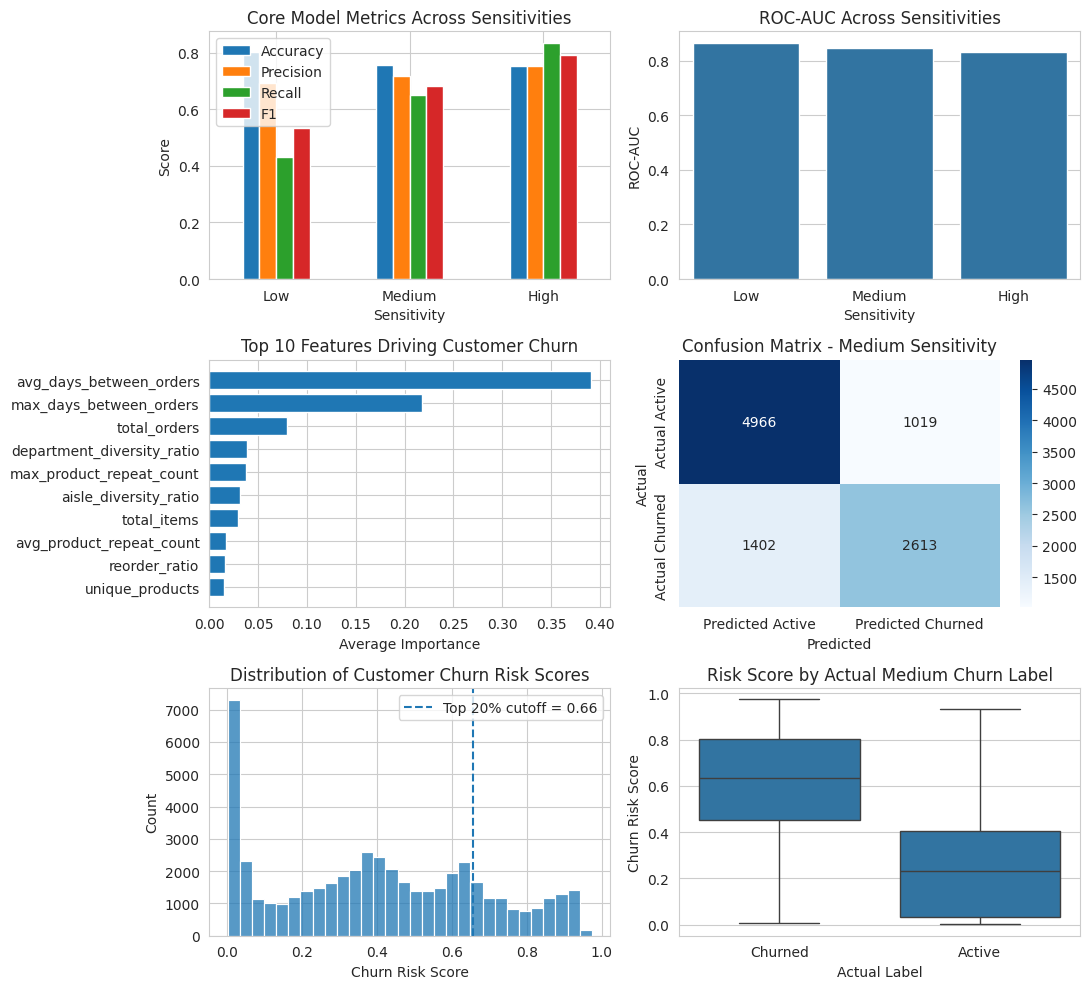

In [51]:
# ============================================================
# CUSTOMER CHURN MODELLING
# DATA PREP, RANDOM FOREST, FEATURE IMPORTANCE,
# CONFUSION MATRIX, HIGH RISK CUSTOMERS, VISUALIZE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

print("========== CUSTOMER CHURN MODELLING - DATA PREP AND PROCESSING ==========")

# Select model features
# This removes identifiers, labels, and direct recency leakage from model input.
feature_cols = customer_features.drop(
    columns=[
        "user_id",
        "churn_low", "churn_medium", "churn_high",
        "last_days_since_prior_order"
    ]
).columns.tolist()

X = customer_features[feature_cols]

# Store labels
# These are the three churn definitions built earlier.
y_map = {
    "Low": customer_features["churn_low"],
    "Medium": customer_features["churn_medium"],
    "High": customer_features["churn_high"]
}

print(f"Number of model features: {len(feature_cols)}")
print("Preview of selected model features:")
display(pd.DataFrame({"Feature": feature_cols}).head(10))

print("========== RANDOM FOREST MODEL ==========")

# Train one random forest per churn sensitivity
# This helps compare how the churn definition changes model behavior.
results = {}
split_data = {}

for sensitivity, y in y_map.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    results[sensitivity] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "metrics": metrics
    }

    split_data[sensitivity] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

print("Random Forest models trained for Low, Medium, and High sensitivity.\n")

# Build model performance table
# This summarizes how each churn definition performs.
metrics_df = pd.DataFrame({
    sensitivity: result["metrics"]
    for sensitivity, result in results.items()
}).T.round(4)

print("Model performance summary:")
display(metrics_df)

print("========== SUMMARIZE FEATURE IMPORTANCE LIST ==========")

# Build feature importance table for each model
# This shows which customer behavior signals matter most.
feature_importance_map = {}

for sensitivity, result in results.items():
    model = result["model"]
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    feature_importance_map[sensitivity] = importance_df

# Average feature importance across all three models
# This gives one stable view of important churn drivers.
avg_importance_df = (
    pd.concat(
        [
            feature_importance_map["Low"].rename(columns={"Importance": "Low_Importance"}),
            feature_importance_map["Medium"][["Feature", "Importance"]].rename(columns={"Importance": "Medium_Importance"}),
            feature_importance_map["High"][["Feature", "Importance"]].rename(columns={"Importance": "High_Importance"})
        ],
        axis=1
    )
)

avg_importance_df = avg_importance_df.loc[:, ~avg_importance_df.columns.duplicated()]
avg_importance_df["Average_Importance"] = avg_importance_df[
    ["Low_Importance", "Medium_Importance", "High_Importance"]
].mean(axis=1)

avg_importance_df = avg_importance_df.sort_values("Average_Importance", ascending=False).reset_index(drop=True)

print("Top feature importance list:")
display(avg_importance_df.head(15).round(4))

print("========== CONFUSION MATRIX ==========")

# Use medium sensitivity as the main practical churn setting
# This gives a balanced view of churn prediction.
medium_y_test = split_data["Medium"]["y_test"]
medium_y_pred = results["Medium"]["y_pred"]

cm = confusion_matrix(medium_y_test, medium_y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Active", "Actual Churned"],
    columns=["Predicted Active", "Predicted Churned"]
)

print("Confusion matrix for Medium sensitivity:")
display(cm_df)

print("========== IDENTIFY HIGH RISK CUSTOMERS ==========")

# Score all customers using the medium model
# This gives a churn risk score for practical targeting.
customer_features["churn_risk_score"] = results["Medium"]["model"].predict_proba(X)[:, 1]

# Flag top 20% highest-risk customers
# These are customers most likely to churn soon.
risk_cutoff = customer_features["churn_risk_score"].quantile(0.80)

high_risk_customers = (
    customer_features[customer_features["churn_risk_score"] >= risk_cutoff]
    .sort_values("churn_risk_score", ascending=False)
    .copy()
)

high_risk_preview = high_risk_customers[
    ["user_id", "churn_risk_score", "churn_medium", "total_orders", "reorder_ratio", "avg_basket_size"]
].head(20)

risk_summary_df = pd.DataFrame({
    "Metric": [
        "Risk Score Cutoff (Top 20%)",
        "High Risk Customer Count",
        "Observed Medium Churn Rate in High Risk Group"
    ],
    "Value": [
        round(risk_cutoff, 4),
        len(high_risk_customers),
        round(high_risk_customers["churn_medium"].mean(), 4)
    ]
})

print("High-risk customer summary:")
display(risk_summary_df)

print("Top high-risk customers:")
display(high_risk_preview)

print("========== VISUALIZE ==========")

# Prepare data for plots
# These tables help explain performance and churn risk visually.
plot_metrics_df = metrics_df.reset_index().rename(columns={"index": "Sensitivity"})
top10_importance = avg_importance_df.head(10).sort_values("Average_Importance", ascending=True)

risk_distribution_df = customer_features[["churn_risk_score", "churn_medium"]].copy()
risk_distribution_df["Medium_Label"] = risk_distribution_df["churn_medium"].map({0: "Active", 1: "Churned"})

# Create 6 plots in a 3x2 layout
# These plots summarize the full modelling section clearly.
fig, axes = plt.subplots(3, 2, figsize=(11, 10))
axes = axes.flatten()

# Plot 1: Accuracy, precision, recall, F1 across sensitivities
# This compares the core model metrics.
plot_metrics_df.plot(
    x="Sensitivity",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Core Model Metrics Across Sensitivities")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=0)

# Plot 2: ROC-AUC across sensitivities
# This compares ranking quality of the three models.
sns.barplot(data=plot_metrics_df, x="Sensitivity", y="ROC_AUC", ax=axes[1])
axes[1].set_title("ROC-AUC Across Sensitivities")
axes[1].set_ylabel("ROC-AUC")

# Plot 3: Top average feature importance
# This highlights the strongest churn drivers.
axes[2].barh(top10_importance["Feature"], top10_importance["Average_Importance"])
axes[2].set_title("Top 10 Features Driving Customer Churn")
axes[2].set_xlabel("Average Importance")

# Plot 4: Confusion matrix heatmap
# This shows correct and incorrect predictions for the medium model.
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[3])
axes[3].set_title("Confusion Matrix - Medium Sensitivity")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Actual")

# Plot 5: Risk score distribution
# This shows how churn risk scores are spread across customers.
sns.histplot(customer_features["churn_risk_score"], bins=30, ax=axes[4])
axes[4].axvline(risk_cutoff, linestyle="--", label=f"Top 20% cutoff = {risk_cutoff:.2f}")
axes[4].set_title("Distribution of Customer Churn Risk Scores")
axes[4].set_xlabel("Churn Risk Score")
axes[4].set_ylabel("Count")
axes[4].legend()

# Plot 6: Risk score by actual medium churn label
# This checks whether churned users receive higher scores.
sns.boxplot(data=risk_distribution_df, x="Medium_Label", y="churn_risk_score", ax=axes[5])
axes[5].set_title("Risk Score by Actual Medium Churn Label")
axes[5].set_xlabel("Actual Label")
axes[5].set_ylabel("Churn Risk Score")

plt.tight_layout()
plt.show()

For the customer churn modelling, we trained Random Forest models across low, medium, and high churn definitions using behavioral features while avoiding recency leakage. The models perform consistently well, with ROC-AUC scores of 0.864 (Low), 0.848 (Medium), and 0.831 (High), indicating strong predictive power. The medium sensitivity setting provides the best balance (~75.8% accuracy, 68.3% F1), making it suitable for practical use. Feature importance aligns with earlier insights, with order frequency and inactivity patterns (avg/max days between orders) emerging as the dominant drivers. The model is also actionable, top 20% high-risk customers show an observed churn rate of ~88%, confirming that behavioral signals can effectively identify customers at risk.

### Customer Churn and Product Decay

========== PRODUCT CHURN AND CUSTOMER CHURN ==========
Recent-vs-historical windows created successfully.

========== BUILD PRODUCT-LEVEL TEMPORAL DECAY ==========
Product-level temporal decay created successfully.

========== AGGREGATE PRODUCT CHURN ==========
Customer-level product churn summary:


,user_id,total_historical_products,churned_products,total_historical_purchases,total_recent_purchases,product_churn_ratio
0,5,22,20,34.0,2.0,0.909091
1,7,68,66,203.0,3.0,0.970588
2,12,60,58,71.0,2.0,0.966667
3,13,29,29,78.0,3.0,1.000000
4,21,99,99,202.0,0.0,1.000000


========== WEIGHTED PRODUCT CHURN VIEW ==========
Product churn metrics summary:


,Metric,Value
0,Average Product Churn Ratio,0.9508
1,Average Weighted Product Churn Ratio,0.9456
2,Average Churned Products,62.9385
3,Correlation: Product Churn Ratio vs Medium Churn,-0.1125
4,Correlation: Weighted Product Churn Ratio vs Medium Churn,-0.1235


Product churn comparison by customer churn group:


,churn_medium,product_churn_ratio,weighted_product_churn_ratio,churned_products,total_historical_products
0,Active,0.9605,0.9572,74.1489,75.1820
1,Churned,0.9364,0.9283,46.2289,47.4222


========== VISUALIZE ==========


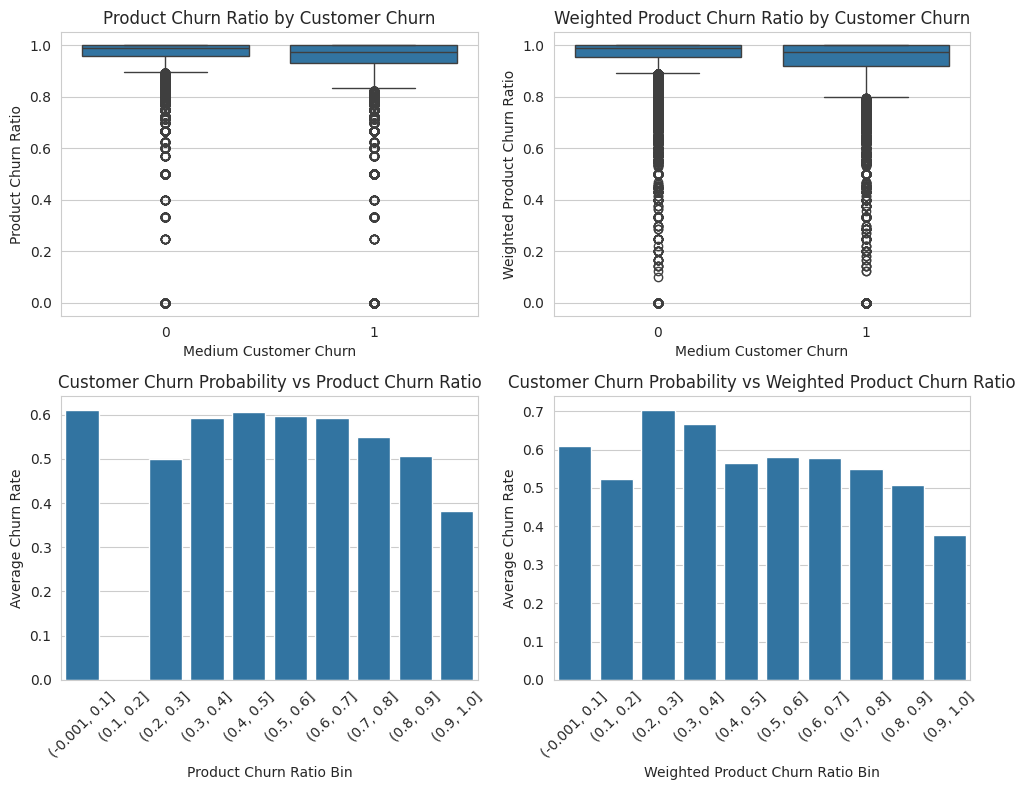

In [52]:
# ============================================================
# PRODUCT CHURN AND CUSTOMER CHURN
# BUILD TEMPORAL PRODUCT DECAY, AGGREGATE CHURN,
# SUMMARIZE, VISUALIZE
# ============================================================

print("========== PRODUCT CHURN AND CUSTOMER CHURN ==========")

# Sort purchase history in customer order sequence
# This is needed to separate historical behavior from recent behavior.
prior_sorted = prior_data.sort_values(["user_id", "order_number"]).copy()

# Define a recent window using the last N orders
# This lets us compare recent product interaction against older behavior.
recent_n_orders = 3

# Mark each row as belonging to the recent or historical window
# Recent rows come from the last N orders of each customer.
prior_sorted["order_rank_desc"] = (
    prior_sorted.groupby("user_id")["order_number"]
    .rank(method="first", ascending=False)
)

prior_sorted["is_recent_window"] = (
    prior_sorted["order_rank_desc"] <= recent_n_orders
).astype(int)

print("Recent-vs-historical windows created successfully.\n")

print("========== BUILD PRODUCT-LEVEL TEMPORAL DECAY ==========")

# Count product usage in historical and recent windows
# This captures whether a previously used product is fading over time.
product_window_counts = (
    prior_sorted.groupby(["user_id", "product_id", "is_recent_window"], as_index=False)
    .agg(
        purchase_count=("order_id", "count"),
        reorder_count=("reordered", "sum")
    )
)

# Reshape into one row per customer-product pair
# This gives direct historical vs recent comparison for each product.
product_window_pivot = (
    product_window_counts.pivot_table(
        index=["user_id", "product_id"],
        columns="is_recent_window",
        values="purchase_count",
        fill_value=0
    )
    .reset_index()
)

product_window_pivot.columns.name = None
product_window_pivot = product_window_pivot.rename(columns={
    0: "historical_purchase_count",
    1: "recent_purchase_count"
})

# Make sure both columns exist even in edge cases
# Some users may only appear in one side of the split.
if "historical_purchase_count" not in product_window_pivot.columns:
    product_window_pivot["historical_purchase_count"] = 0
if "recent_purchase_count" not in product_window_pivot.columns:
    product_window_pivot["recent_purchase_count"] = 0

# Keep only products with some historical presence
# This prevents new/recent-only products from being treated as decayed.
product_window_pivot = product_window_pivot[
    product_window_pivot["historical_purchase_count"] > 0
].copy()

# Build decay ratio
# A low ratio means the customer's recent interaction has dropped sharply.
product_window_pivot["decay_ratio"] = (
    product_window_pivot["recent_purchase_count"] /
    product_window_pivot["historical_purchase_count"]
)

# Flag product churn using temporal decay
# Products with strong recent drop are treated as churned products.
decay_threshold = 0.30

product_window_pivot["product_churn_flag"] = (
    product_window_pivot["decay_ratio"] <= decay_threshold
).astype(int)

print("Product-level temporal decay created successfully.\n")

print("========== AGGREGATE PRODUCT CHURN ==========")

# Aggregate simple product churn metrics at customer level
# This summarizes how much of a customer's historical product set is fading.
product_churn_per_user = (
    product_window_pivot.groupby("user_id", as_index=False)
    .agg(
        total_historical_products=("product_id", "count"),
        churned_products=("product_churn_flag", "sum"),
        total_historical_purchases=("historical_purchase_count", "sum"),
        total_recent_purchases=("recent_purchase_count", "sum")
    )
)

product_churn_per_user["product_churn_ratio"] = (
    product_churn_per_user["churned_products"] /
    product_churn_per_user["total_historical_products"]
)

print("Customer-level product churn summary:")
display(product_churn_per_user.head())

print("========== WEIGHTED PRODUCT CHURN VIEW ==========")

# Build weighted churn score using historical purchase count
# Losing a heavily used product should matter more than losing a weak one.
product_window_pivot["weighted_churn_purchase"] = (
    product_window_pivot["product_churn_flag"] *
    product_window_pivot["historical_purchase_count"]
)

weighted_product_churn_per_user = (
    product_window_pivot.groupby("user_id", as_index=False)
    .agg(
        weighted_churn_purchase_sum=("weighted_churn_purchase", "sum"),
        total_historical_purchase_weight=("historical_purchase_count", "sum")
    )
)

weighted_product_churn_per_user["weighted_product_churn_ratio"] = (
    weighted_product_churn_per_user["weighted_churn_purchase_sum"] /
    weighted_product_churn_per_user["total_historical_purchase_weight"]
)

# Merge all product churn views into customer analysis table
# This connects product-level disengagement to customer churn behavior.
customer_analysis = customer_features.merge(
    product_churn_per_user,
    on="user_id",
    how="left"
).merge(
    weighted_product_churn_per_user[["user_id", "weighted_product_churn_ratio"]],
    on="user_id",
    how="left"
)

churn_fill_cols = [
    "total_historical_products", "churned_products",
    "total_historical_purchases", "total_recent_purchases",
    "product_churn_ratio", "weighted_product_churn_ratio"
]
customer_analysis[churn_fill_cols] = customer_analysis[churn_fill_cols].fillna(0)

# Build summary tables
# These summarize the relationship between product churn and customer churn.
product_churn_summary_df = pd.DataFrame({
    "Metric": [
        "Average Product Churn Ratio",
        "Average Weighted Product Churn Ratio",
        "Average Churned Products",
        "Correlation: Product Churn Ratio vs Medium Churn",
        "Correlation: Weighted Product Churn Ratio vs Medium Churn"
    ],
    "Value": [
        round(customer_analysis["product_churn_ratio"].mean(), 4),
        round(customer_analysis["weighted_product_churn_ratio"].mean(), 4),
        round(customer_analysis["churned_products"].mean(), 4),
        round(customer_analysis[["product_churn_ratio", "churn_medium"]].corr().iloc[0, 1], 4),
        round(customer_analysis[["weighted_product_churn_ratio", "churn_medium"]].corr().iloc[0, 1], 4)
    ]
})

product_churn_by_customer_df = (
    customer_analysis.groupby("churn_medium")[
        [
            "product_churn_ratio",
            "weighted_product_churn_ratio",
            "churned_products",
            "total_historical_products"
        ]
    ]
    .mean()
    .round(4)
    .reset_index()
)

product_churn_by_customer_df["churn_medium"] = product_churn_by_customer_df["churn_medium"].map({
    0: "Active",
    1: "Churned"
})

print("Product churn metrics summary:")
display(product_churn_summary_df)

print("Product churn comparison by customer churn group:")
display(product_churn_by_customer_df)

print("========== VISUALIZE ==========")

# Create bins for smooth churn trend plots
# This shows how customer churn changes as product churn becomes more severe.
customer_analysis["product_churn_bin"] = pd.cut(
    customer_analysis["product_churn_ratio"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

customer_analysis["weighted_product_churn_bin"] = pd.cut(
    customer_analysis["weighted_product_churn_ratio"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

churn_by_product_churn = (
    customer_analysis.groupby("product_churn_bin", observed=False)["churn_medium"]
    .mean()
    .reset_index()
)

churn_by_weighted_product_churn = (
    customer_analysis.groupby("weighted_product_churn_bin", observed=False)["churn_medium"]
    .mean()
    .reset_index()
)

# Create 4 plots in a 2x2 layout
# These plots summarize the product churn and customer churn relationship.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Plot 1: Product churn ratio by customer churn group
# This compares simple product churn between active and churned customers.
sns.boxplot(data=customer_analysis, x="churn_medium", y="product_churn_ratio", ax=axes[0])
axes[0].set_title("Product Churn Ratio by Customer Churn")
axes[0].set_xlabel("Medium Customer Churn")
axes[0].set_ylabel("Product Churn Ratio")

# Plot 2: Weighted product churn ratio by customer churn group
# This compares the weighted product churn view across churn groups.
sns.boxplot(data=customer_analysis, x="churn_medium", y="weighted_product_churn_ratio", ax=axes[1])
axes[1].set_title("Weighted Product Churn Ratio by Customer Churn")
axes[1].set_xlabel("Medium Customer Churn")
axes[1].set_ylabel("Weighted Product Churn Ratio")

# Plot 3: Customer churn probability vs simple product churn
# This shows whether customer churn rises with higher product churn.
sns.barplot(data=churn_by_product_churn, x="product_churn_bin", y="churn_medium", ax=axes[2])
axes[2].set_title("Customer Churn Probability vs Product Churn Ratio")
axes[2].set_xlabel("Product Churn Ratio Bin")
axes[2].set_ylabel("Average Churn Rate")
axes[2].tick_params(axis="x", rotation=45)

# Plot 4: Customer churn probability vs weighted product churn
# This shows whether weighted product churn gives a stronger pattern.
sns.barplot(data=churn_by_weighted_product_churn, x="weighted_product_churn_bin", y="churn_medium", ax=axes[3])
axes[3].set_title("Customer Churn Probability vs Weighted Product Churn Ratio")
axes[3].set_xlabel("Weighted Product Churn Ratio Bin")
axes[3].set_ylabel("Average Churn Rate")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

For the product churn and customer churn, we introduced a temporal product decay approach that compares recent vs historical product interaction to capture disengagement. While the method is conceptually aligned with the project goal, the current results do not yet support the hypothesis: the average product churn ratio is very high (~0.95) and shows a slightly negative correlation with customer churn (~ -0.11). Additionally, active customers exhibit similar or even higher churn ratios than churned users, indicating that the definition is still too aggressive and not distinguishing meaningful product-level decline. This suggests that while the approach is correct in direction, further refinement is needed to accurately capture product churn as a driver of customer churn.

### Part 1 Conclusion

Overall, the customer churn analysis shows that churn can be reliably predicted using behavioral signals such as recency, reorder patterns, and product loyalty. The model achieves strong performance and successfully identifies high-risk customers, confirming that churn is driven by gradual disengagement rather than sudden drop-off. These results establish a clear foundation for the project by demonstrating that customer behavior is predictable and, importantly, closely tied to how users interact with products, setting up the next step of linking customer churn with product-level dynamics.

## Part 2: Product Churn

### Product Churn Definition

In addition to customer churn, it is equally important to understand product-level demand dynamics. A product can be considered to be “churning” if it experiences a decline in demand or reduced repeat purchase behavior over time. Identifying such products allows platforms to take corrective actions such as promotions, bundling, or improved recommendations.

In this section, we define product churn using multiple sensitivity levels
Compare rule-based and machine learning-based approaches and analyze churn across product, aisle, and department levels

========== PRODUCT CHURN - DATA PREP ==========
Product feature table built successfully.

========== THRESHOLD AND DATA PREP AGAIN ==========
Product churn labels created successfully.

========== SUMMARY OF DATA PREP ==========
Product feature table shape:


,Metric,Value
0,Rows,46904
1,Columns,12
2,Engineered Features Excluding product_id,11


Missing value check:


,Metric,Value
0,Numeric Missing Values Remaining,0


Reorder rate summary:


...

Product churn summary table:


,Sensitivity,Reorder_Rate_Threshold,Churned_Products,Active_Products,Churn_Rate
0,Low,0.096774,11729,35175,0.250064
1,Medium,0.260000,18765,28139,0.400072
2,High,0.386364,25807,21097,0.550209


Preview of product feature table:


,product_id,total_purchases,unique_users,reorder_rate,avg_days_between_orders,avg_order_number,last_order_number,aisle,department,churn_low,churn_medium,churn_high
0,1,356,150,0.578652,10.191045,22.780899,97,cookies cakes,snacks,0,0,0
1,2,20,19,0.050000,9.789474,23.500000,91,spices seasonings,pantry,1,1,1
2,3,116,17,0.853448,8.276786,22.991379,91,tea,beverages,0,0,0
3,4,74,43,0.418919,12.671875,7.391892,44,frozen meals,frozen,0,0,0
4,5,4,3,0.250000,17.500000,5.000000,7,marinades meat preparation,pantry,0,1,1


========== VISUALIZE ==========


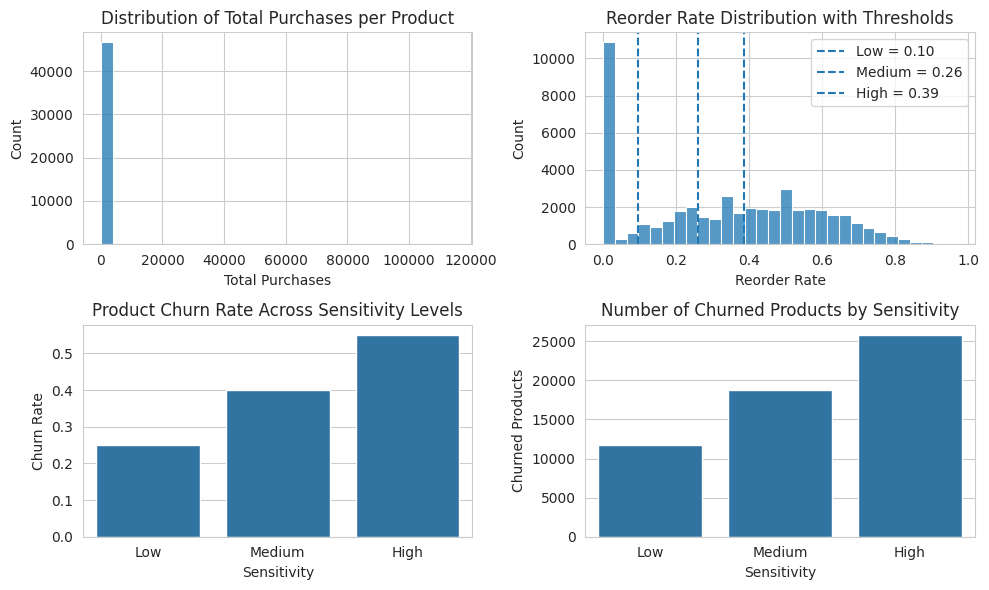

In [53]:
# ============================================================
# PRODUCT CHURN - DATA PREP, THRESHOLDS, SUMMARY, VISUALIZE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("========== PRODUCT CHURN - DATA PREP ==========")

# Build base product-level behavior features
# This summarizes demand, user reach, repeat buying, and ordering behavior.
product_features = (
    prior_data.groupby("product_id")
    .agg(
        total_purchases=("order_id", "count"),
        unique_users=("user_id", "nunique"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        avg_order_number=("order_number", "mean")
    )
    .reset_index()
)

# Add a product recency-style proxy
# This captures how recently the product remained active in orders.
product_last_order = (
    prior_data.sort_values(["product_id", "order_number"])
    .groupby("product_id", as_index=False)
    .tail(1)[["product_id", "order_number"]]
    .rename(columns={"order_number": "last_order_number"})
)

product_features = product_features.merge(
    product_last_order,
    on="product_id",
    how="left"
)

# Add basic product metadata if available
# This helps later analysis at aisle and department level.
if "products_enriched" in globals():
    product_features = product_features.merge(
        products_enriched[["product_id", "aisle", "department"]],
        on="product_id",
        how="left"
    )

# Clean missing and infinite values
# This keeps the product feature table ready for summaries and modeling.
product_features = product_features.replace([np.inf, -np.inf], np.nan)
numeric_cols_prod = product_features.select_dtypes(include=[np.number]).columns
product_features[numeric_cols_prod] = product_features[numeric_cols_prod].fillna(0)

print("Product feature table built successfully.\n")

print("========== THRESHOLD AND DATA PREP AGAIN ==========")

# Summarize reorder rate
# This is the main signal used to define product churn.
reorder_summary = product_features["reorder_rate"].describe().to_frame("Value")

# Define product churn thresholds using quantiles
# Lower reorder rate means weaker repeat demand and higher churn risk.
low_thr = product_features["reorder_rate"].quantile(0.25)
med_thr = product_features["reorder_rate"].quantile(0.40)
high_thr = product_features["reorder_rate"].quantile(0.55)

# Store thresholds in a table
# This makes the three churn definitions easy to compare.
threshold_df_prod = pd.DataFrame({
    "Sensitivity": ["Low", "Medium", "High"],
    "Reorder_Rate_Threshold": [low_thr, med_thr, high_thr]
})

# Create product churn labels
# A product is churned if reorder rate is below or equal to the threshold.
product_features["churn_low"] = (product_features["reorder_rate"] <= low_thr).astype(int)
product_features["churn_medium"] = (product_features["reorder_rate"] <= med_thr).astype(int)
product_features["churn_high"] = (product_features["reorder_rate"] <= high_thr).astype(int)

print("Product churn labels created successfully.\n")

print("========== SUMMARY OF DATA PREP ==========")

# Build shape table
# This shows the size of the product-level dataset.
shape_df_prod = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Engineered Features Excluding product_id"],
    "Value": [
        product_features.shape[0],
        product_features.shape[1],
        product_features.shape[1] - 1
    ]
})

# Build missing-value check
# This confirms the table is clean for downstream steps.
missing_check_prod = pd.DataFrame({
    "Metric": ["Numeric Missing Values Remaining"],
    "Value": [product_features[numeric_cols_prod].isnull().sum().sum()]
})

# Summarize churn counts and rates
# This shows how many products are churned under each threshold setting.
product_churn_summary_df = pd.DataFrame({
    "Sensitivity": ["Low", "Medium", "High"],
    "Reorder_Rate_Threshold": [low_thr, med_thr, high_thr],
    "Churned_Products": [
        product_features["churn_low"].sum(),
        product_features["churn_medium"].sum(),
        product_features["churn_high"].sum()
    ],
    "Active_Products": [
        len(product_features) - product_features["churn_low"].sum(),
        len(product_features) - product_features["churn_medium"].sum(),
        len(product_features) - product_features["churn_high"].sum()
    ],
    "Churn_Rate": [
        product_features["churn_low"].mean(),
        product_features["churn_medium"].mean(),
        product_features["churn_high"].mean()
    ]
})

print("Product feature table shape:")
display(shape_df_prod)

print("Missing value check:")
display(missing_check_prod)

print("Reorder rate summary:")
display(reorder_summary)

print("Threshold table:")
display(threshold_df_prod)

print("Product churn summary table:")
display(product_churn_summary_df)

print("Preview of product feature table:")
display(product_features.head())

print("========== VISUALIZE ==========")

# Build helper tables for plotting
# These support clean churn summary visualizations.
product_churn_rates_plot = product_churn_summary_df[["Sensitivity", "Churn_Rate"]].copy()
product_churn_counts_plot = product_churn_summary_df[["Sensitivity", "Churned_Products"]].copy()

# Create 4 plots in a 2x2 layout
# These plots explain the full product churn setup clearly.
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

# Plot 1: Total purchases distribution
# This shows how product demand is distributed overall.
sns.histplot(product_features["total_purchases"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Total Purchases per Product")
axes[0].set_xlabel("Total Purchases")
axes[0].set_ylabel("Count")

# Plot 2: Reorder rate distribution with thresholds
# This shows where the three churn cutoffs fall.
sns.histplot(product_features["reorder_rate"], bins=30, ax=axes[1])
axes[1].axvline(low_thr, linestyle="--", label=f"Low = {low_thr:.2f}")
axes[1].axvline(med_thr, linestyle="--", label=f"Medium = {med_thr:.2f}")
axes[1].axvline(high_thr, linestyle="--", label=f"High = {high_thr:.2f}")
axes[1].set_title("Reorder Rate Distribution with Thresholds")
axes[1].set_xlabel("Reorder Rate")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot 3: Product churn rate across sensitivities
# This shows how product churn changes as sensitivity increases.
sns.barplot(data=product_churn_rates_plot, x="Sensitivity", y="Churn_Rate", ax=axes[2])
axes[2].set_title("Product Churn Rate Across Sensitivity Levels")
axes[2].set_xlabel("Sensitivity")
axes[2].set_ylabel("Churn Rate")

# Plot 4: Number of churned products
# This shows class balance under each definition.
sns.barplot(data=product_churn_counts_plot, x="Sensitivity", y="Churned_Products", ax=axes[3])
axes[3].set_title("Number of Churned Products by Sensitivity")
axes[3].set_xlabel("Sensitivity")
axes[3].set_ylabel("Churned Products")

plt.tight_layout()
plt.show()

### Product Churn Sensitivity

========== EXAMINE MULTIPLE DISTRIBUTIONS ==========
========== SUMMARIZE ==========
Low sensitivity summary:


reorder_rate        total_purchases        unique_users         \
                  mean median            mean median         mean median   
churn_low                                                                  
0                0.443  0.444         223.419   31.0       90.486   17.0   
1                0.005  0.000           5.878    2.0        5.677    2.0   

          avg_days_between_orders         avg_order_number          \
                             mean  median             mean  median   
churn_low                                                            
0                          11.582  11.333           15.316  14.505   
1                          11.834  11.000           13.123  10.083   

          last_order_number         
                       mean median  
churn_low                           
0                    56.485   56.0  
1                    24.892   18.0

Medium sensitivity summary:


reorder_rate        total_purchases        unique_users         \
                     mean median            mean median         mean median   
churn_medium                                                                  
0                   0.506    0.5         270.067   42.0      105.692   21.0   
1                   0.075    0.0          17.495    4.0       14.675    4.0   

             avg_days_between_orders        avg_order_number          \
                                mean median             mean  median   
churn_medium                                                           
0                             11.487  11.25           15.649  14.879   
1                             11.882  11.40           13.446  11.643   

             last_order_number         
                          mean median  
churn_medium                           
0                       58.867   59.0  
1                       33.166   26.0

High sensitivity summary:


reorder_rate        total_purchases        unique_users         \
                   mean median            mean median         mean median   
churn_high                                                                  
0                 0.566  0.550         336.018   55.0      124.801   23.0   
1                 0.143  0.136          32.500    7.0       23.890    6.0   

           avg_days_between_orders         avg_order_number          \
                              mean  median             mean  median   
churn_high                                                            
0                           11.311  11.109           16.106  15.373   
1                           11.918  11.545           13.674  12.214   

           last_order_number         
                        mean median  
churn_high                           
0                     60.905   63.0  
1                     38.513   33.0

Combined comparison table:


,Sensitivity,Group,reorder_rate,total_purchases,unique_users,avg_days_between_orders,avg_order_number,last_order_number
0,Low,Active,0.443,223.419,90.486,11.582,15.316,56.485
1,Low,Churned,0.005,5.878,5.677,11.834,13.123,24.892
2,Medium,Active,0.506,270.067,105.692,11.487,15.649,58.867
3,Medium,Churned,0.075,17.495,14.675,11.882,13.446,33.166
4,High,Active,0.566,336.018,124.801,11.311,16.106,60.905
5,High,Churned,0.143,32.500,23.890,11.918,13.674,38.513


========== VISUALIZE ==========


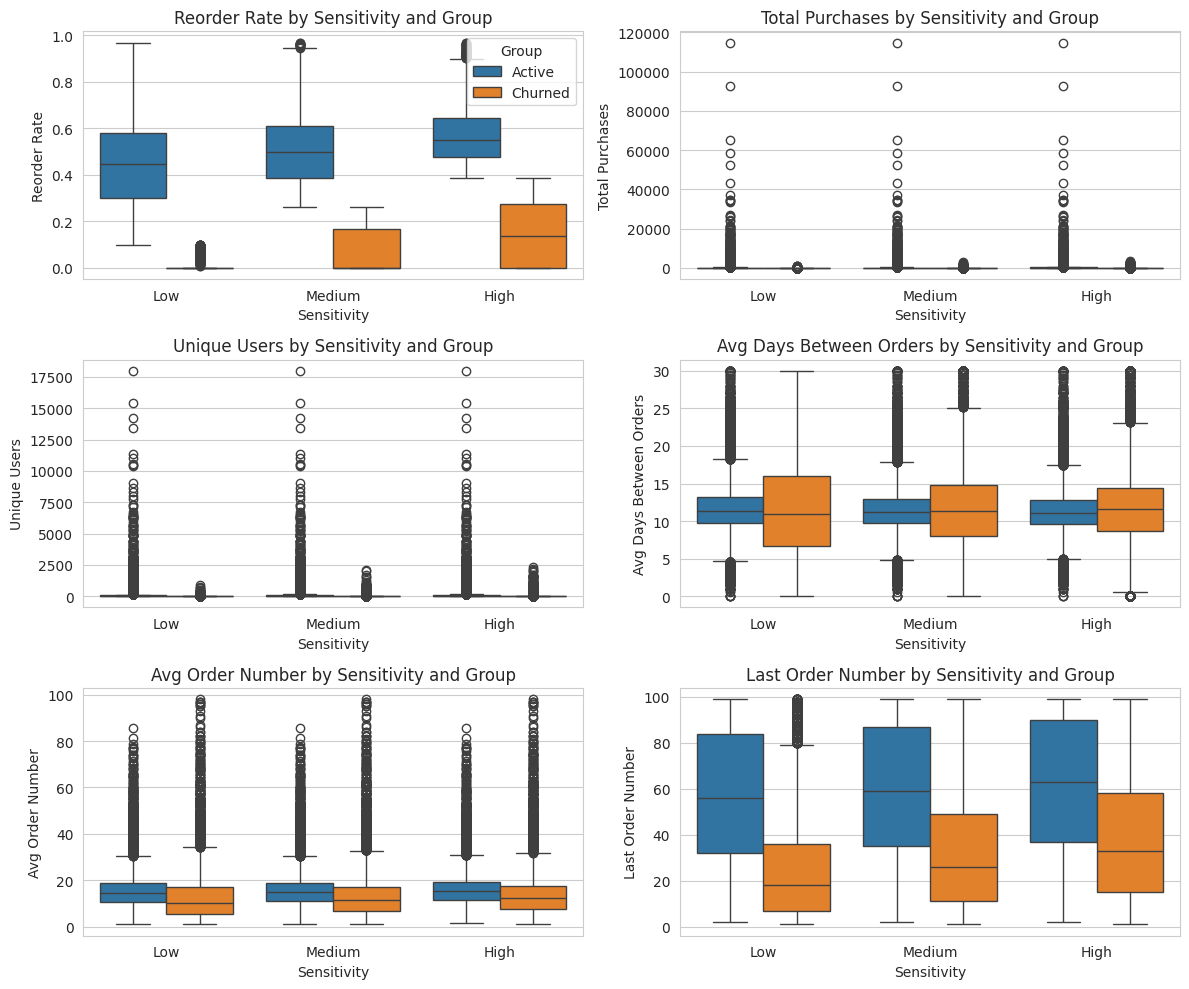

In [54]:
# ============================================================
# PRODUCT CHURN
# EXAMINE MULTIPLE DISTRIBUTIONS, SUMMARIZE, VISUALIZE
# ============================================================

print("========== EXAMINE MULTIPLE DISTRIBUTIONS ==========")

# Select product behavior features to compare
# These are the key signals linked to product churn.
compare_cols_prod = [
    "reorder_rate",
    "total_purchases",
    "unique_users",
    "avg_days_between_orders",
    "avg_order_number",
    "last_order_number"
]

# Build grouped summaries for each churn sensitivity
# This compares churned and active products across thresholds.
summary_low_prod = (
    product_features.groupby("churn_low")[compare_cols_prod]
    .agg(["mean", "median"])
    .round(3)
)

summary_medium_prod = (
    product_features.groupby("churn_medium")[compare_cols_prod]
    .agg(["mean", "median"])
    .round(3)
)

summary_high_prod = (
    product_features.groupby("churn_high")[compare_cols_prod]
    .agg(["mean", "median"])
    .round(3)
)

# Build one compact comparison table
# This gives a clean average view across all sensitivity levels.
def build_product_comparison_table(label_col, sensitivity_name):
    temp = (
        product_features.groupby(label_col)[compare_cols_prod]
        .mean()
        .reset_index()
        .rename(columns={label_col: "Group"})
    )
    temp["Group"] = temp["Group"].map({0: "Active", 1: "Churned"})
    temp["Sensitivity"] = sensitivity_name
    return temp

comparison_table_prod = pd.concat([
    build_product_comparison_table("churn_low", "Low"),
    build_product_comparison_table("churn_medium", "Medium"),
    build_product_comparison_table("churn_high", "High")
], ignore_index=True)

comparison_table_prod = comparison_table_prod[
    ["Sensitivity", "Group"] + compare_cols_prod
].round(3)

print("========== SUMMARIZE ==========")

print("Low sensitivity summary:")
display(summary_low_prod)

print("Medium sensitivity summary:")
display(summary_medium_prod)

print("High sensitivity summary:")
display(summary_high_prod)

print("Combined comparison table:")
display(comparison_table_prod)

print("========== VISUALIZE ==========")

# Reshape product data for comparison plots
# This helps compare active and churned products side by side.
plot_frames_prod = []
for label_col, label_name in [("churn_low", "Low"), ("churn_medium", "Medium"), ("churn_high", "High")]:
    temp = product_features[[label_col] + compare_cols_prod].copy()
    temp["Sensitivity"] = label_name
    temp["Group"] = temp[label_col].map({0: "Active", 1: "Churned"})
    plot_frames_prod.append(temp.drop(columns=[label_col]))

plot_df_prod = pd.concat(plot_frames_prod, ignore_index=True)

# Create 6 comparison plots in a 3x2 layout
# These show how churned and active products differ across thresholds.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Reorder rate comparison
# Churned products should have weaker repeat demand.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="reorder_rate", hue="Group", ax=axes[0])
axes[0].set_title("Reorder Rate by Sensitivity and Group")
axes[0].set_xlabel("Sensitivity")
axes[0].set_ylabel("Reorder Rate")

# Plot 2: Total purchases comparison
# This shows whether churned products have lower overall demand.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="total_purchases", hue="Group", ax=axes[1])
axes[1].set_title("Total Purchases by Sensitivity and Group")
axes[1].set_xlabel("Sensitivity")
axes[1].set_ylabel("Total Purchases")

# Plot 3: Unique users comparison
# This checks whether churned products reach fewer customers.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="unique_users", hue="Group", ax=axes[2])
axes[2].set_title("Unique Users by Sensitivity and Group")
axes[2].set_xlabel("Sensitivity")
axes[2].set_ylabel("Unique Users")

# Plot 4: Avg days between orders comparison
# This shows whether churned products appear with slower repeat timing.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="avg_days_between_orders", hue="Group", ax=axes[3])
axes[3].set_title("Avg Days Between Orders by Sensitivity and Group")
axes[3].set_xlabel("Sensitivity")
axes[3].set_ylabel("Avg Days Between Orders")

# Plot 5: Avg order number comparison
# This checks where churned products tend to appear in order progression.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="avg_order_number", hue="Group", ax=axes[4])
axes[4].set_title("Avg Order Number by Sensitivity and Group")
axes[4].set_xlabel("Sensitivity")
axes[4].set_ylabel("Avg Order Number")

# Plot 6: Last order number comparison
# This gives a proxy view of recent product activity.
sns.boxplot(data=plot_df_prod, x="Sensitivity", y="last_order_number", hue="Group", ax=axes[5])
axes[5].set_title("Last Order Number by Sensitivity and Group")
axes[5].set_xlabel("Sensitivity")
axes[5].set_ylabel("Last Order Number")

# Keep legends neat
# This avoids repeated legend clutter.
for i, ax in enumerate(axes):
    if i != 0:
        ax.get_legend().remove()

axes[0].legend(title="Group")

plt.tight_layout()
plt.show()

We constructed a product-level feature table capturing demand, user reach, reorder behavior, and activity signals, and defined product churn using reorder-rate thresholds at three sensitivity levels. The thresholds (~0.10, 0.28, 0.39) produce stable and interpretable churn rates of 25%, 40%, and 55%, mirroring the customer churn setup. The distribution of total purchases confirms a strong long-tail pattern, where most products have low demand while a few dominate, and the reorder-rate distribution clearly separates weak vs strong repeat-demand products. This validates reorder rate as a reliable proxy for product churn and ensures a well-balanced setup for further analysis.

Across all sensitivity levels, churned products consistently show significantly weaker engagement than active ones. For example, under medium sensitivity, active products have a reorder rate of \~0.50 vs \~0.075 for churned products, along with much higher demand (\~270 vs \~17 total purchases) and broader user reach (\~106 vs \~15 users). Churned products also appear earlier in order timelines, indicating reduced recent activity. These consistent patterns confirm that product churn is driven by declining repeat demand and lower engagement, aligning well with the project’s goal of linking product-level behavior to overall platform dynamics and enabling comparison with machine learning-based churn detection in the next stage.

### Product Churn Rule-based vs Machine Learning-based Modelling

========== RULE-BASED AND MACHINE LEARNING-BASED PRODUCT CHURN ANALYSIS ==========
Rule-based churn labels created successfully.

========== ML MODEL INPUTS AND TRAINING ==========
ML-based product churn model trained successfully.

========== FEATURE IMPORTANCE ==========
Top product churn features:


,Feature,Importance
0,total_purchases,0.5642
1,unique_users,0.3372
2,last_order_number,0.0601
3,avg_order_number,0.0239
4,avg_days_between_orders,0.0147


========== COMPARE PREDICTIONS ==========
========== SUMMARIZE ==========
Rule-based metrics against medium churn label:


,Metric,Rule_Based
0,Accuracy,0.9326
1,Precision,1.0000
2,Recall,0.8316
3,F1,0.9081


ML-based metrics on held-out test data:


...

Prediction pattern counts:


,Rule_Prediction,ML_Prediction,Count
0,Active,Active,29081
1,Active,Churned,2429
2,Churned,Churned,15394


ML confusion matrix:


,Predicted Active,Predicted Churned
Actual Active,5623,5
Actual Churned,219,3534


========== VISUALIZE ==========


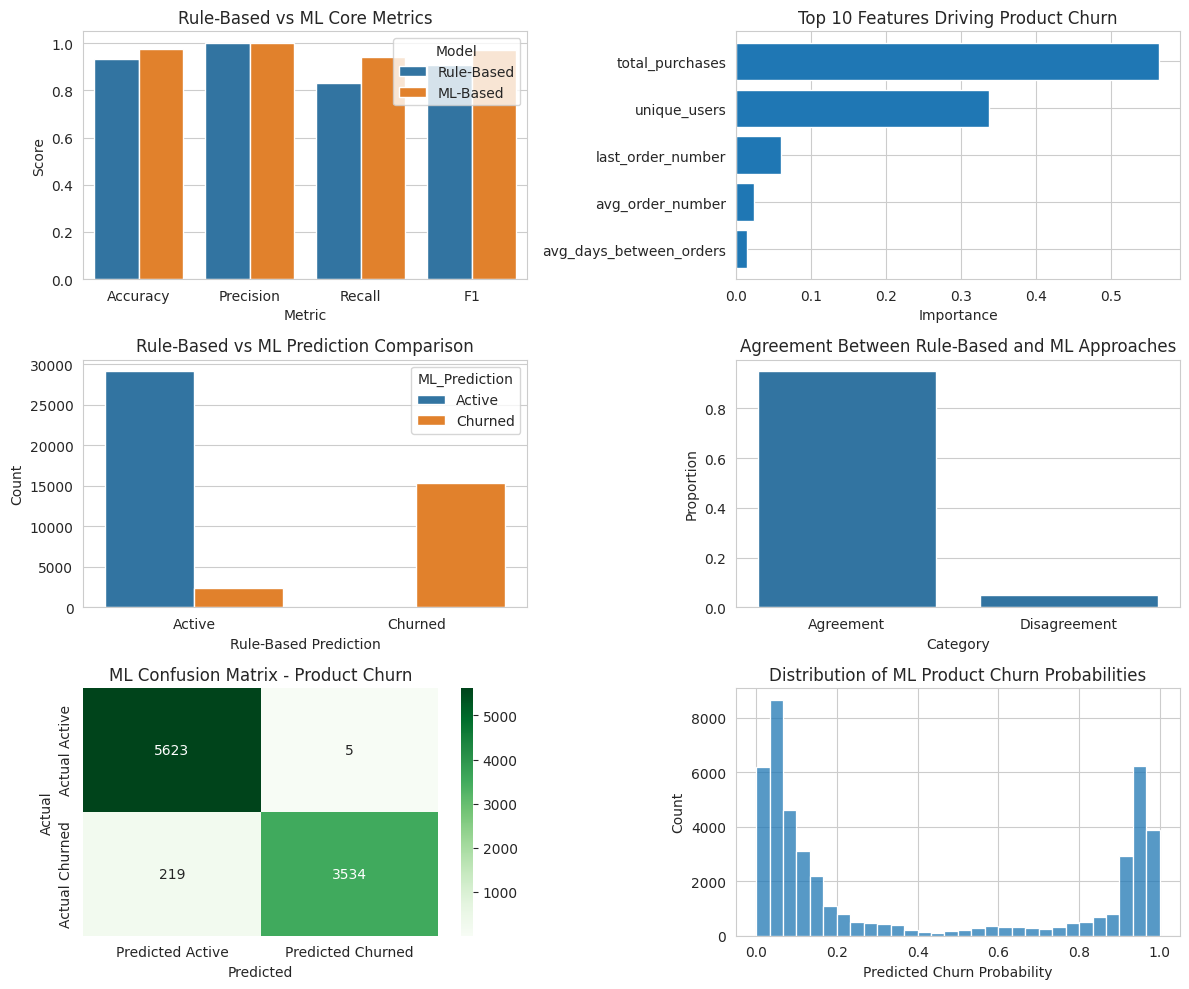

In [55]:
# ============================================================
# RULE-BASED AND MACHINE LEARNING-BASED PRODUCT CHURN ANALYSIS
# MODEL SETUP, TRAINING, FEATURE IMPORTANCE,
# PREDICTION COMPARISON, SUMMARY, VISUALIZE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

print("========== RULE-BASED AND MACHINE LEARNING-BASED PRODUCT CHURN ANALYSIS ==========")

# Create a clean rule-based churn label
# This is a simple interpretable baseline using weak repeat demand and low volume.
product_features["rule_churn"] = (
    (product_features["reorder_rate"] < med_thr) &
    (product_features["total_purchases"] < product_features["total_purchases"].median())
).astype(int)

print("Rule-based churn labels created successfully.\n")

print("========== ML MODEL INPUTS AND TRAINING ==========")

# Prepare ML inputs
# This removes identifiers, labels, rule outputs, and direct label leakage from model input.
drop_cols_prod = [
    "product_id",
    "churn_low", "churn_medium", "churn_high",
    "rule_churn",
    "reorder_rate"
]
optional_drop_cols = [col for col in ["aisle", "department"] if col in product_features.columns]

X_prod = product_features.drop(columns=drop_cols_prod + optional_drop_cols)
y_prod = product_features["churn_medium"]

# Split product data
# Medium sensitivity is used as the main practical churn target.
X_train_prod, X_test_prod, y_train_prod, y_test_prod = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42, stratify=y_prod
)

# Train the product churn model
# Random Forest captures non-linear patterns in product demand behavior.
prod_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

prod_model.fit(X_train_prod, y_train_prod)
y_pred_prod = prod_model.predict(X_test_prod)
y_prob_prod = prod_model.predict_proba(X_test_prod)[:, 1]

print("ML-based product churn model trained successfully.\n")

print("========== FEATURE IMPORTANCE ==========")

# Build feature importance table
# This shows which product signals matter most in prediction.
feature_importance_prod = pd.DataFrame({
    "Feature": X_prod.columns,
    "Importance": prod_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top product churn features:")
display(feature_importance_prod.head(15).round(4))

print("========== COMPARE PREDICTIONS ==========")

# Build rule-based evaluation on the same held-out test rows
# This makes rule-based and ML metrics directly comparable.
rule_test_df = product_features.loc[X_test_prod.index].copy()
rule_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Rule_Based": [
        accuracy_score(rule_test_df["churn_medium"], rule_test_df["rule_churn"]),
        precision_score(rule_test_df["churn_medium"], rule_test_df["rule_churn"], zero_division=0),
        recall_score(rule_test_df["churn_medium"], rule_test_df["rule_churn"], zero_division=0),
        f1_score(rule_test_df["churn_medium"], rule_test_df["rule_churn"], zero_division=0)
    ]
}).round(4)

# Build ML evaluation on held-out test set
# This shows out-of-sample prediction quality.
ml_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "ML_Based": [
        accuracy_score(y_test_prod, y_pred_prod),
        precision_score(y_test_prod, y_pred_prod, zero_division=0),
        recall_score(y_test_prod, y_pred_prod, zero_division=0),
        f1_score(y_test_prod, y_pred_prod, zero_division=0),
        roc_auc_score(y_test_prod, y_prob_prod)
    ]
}).round(4)

# Build direct prediction comparison on the full dataset
# This checks agreement and disagreement between the two approaches.
full_ml_pred = prod_model.predict(X_prod)

comparison_df = pd.DataFrame({
    "Actual_Medium_Churn": product_features["churn_medium"],
    "Rule_Prediction": product_features["rule_churn"],
    "ML_Prediction": full_ml_pred
})

comparison_df["Agreement"] = (
    comparison_df["Rule_Prediction"] == comparison_df["ML_Prediction"]
).astype(int)

agreement_rate = comparison_df["Agreement"].mean()

agreement_summary_df = pd.DataFrame({
    "Metric": [
        "Agreement Rate",
        "Rule Positive Rate",
        "ML Positive Rate",
        "Actual Medium Churn Rate"
    ],
    "Value": [
        round(agreement_rate, 4),
        round(comparison_df["Rule_Prediction"].mean(), 4),
        round(comparison_df["ML_Prediction"].mean(), 4),
        round(comparison_df["Actual_Medium_Churn"].mean(), 4)
    ]
})

# Build rule vs ML prediction pattern counts
# This shows where the two approaches align or differ.
prediction_pattern_counts = (
    comparison_df.groupby(["Rule_Prediction", "ML_Prediction"])
    .size()
    .reset_index(name="Count")
)

prediction_pattern_counts["Rule_Prediction"] = prediction_pattern_counts["Rule_Prediction"].map({0: "Active", 1: "Churned"})
prediction_pattern_counts["ML_Prediction"] = prediction_pattern_counts["ML_Prediction"].map({0: "Active", 1: "Churned"})

# Build confusion matrix for ML test performance
# This shows detailed held-out prediction quality.
cm_prod = confusion_matrix(y_test_prod, y_pred_prod)
cm_prod_df = pd.DataFrame(
    cm_prod,
    index=["Actual Active", "Actual Churned"],
    columns=["Predicted Active", "Predicted Churned"]
)

print("========== SUMMARIZE ==========")

print("Rule-based metrics against medium churn label:")
display(rule_metrics_df)

print("ML-based metrics on held-out test data:")
display(ml_metrics_df)

print("Top feature importance list:")
display(feature_importance_prod.head(10).round(4))

print("Agreement summary:")
display(agreement_summary_df)

print("Prediction pattern counts:")
display(prediction_pattern_counts)

print("ML confusion matrix:")
display(cm_prod_df)

print("========== VISUALIZE ==========")

# Prepare compact plot tables
# These support clean comparison visuals.
rule_plot_df = rule_metrics_df.rename(columns={"Rule_Based": "Value"}).copy()
rule_plot_df["Model"] = "Rule-Based"

ml_plot_df = ml_metrics_df[ml_metrics_df["Metric"] != "ROC_AUC"].rename(columns={"ML_Based": "Value"}).copy()
ml_plot_df["Model"] = "ML-Based"

metrics_compare_plot = pd.concat([rule_plot_df, ml_plot_df], ignore_index=True)

top10_prod_features = feature_importance_prod.head(10).sort_values("Importance", ascending=True)

agreement_plot_df = pd.DataFrame({
    "Category": ["Agreement", "Disagreement"],
    "Proportion": [agreement_rate, 1 - agreement_rate]
})

# Create 6 plots in a 3x2 layout
# These plots summarize the rule-based vs ML comparison clearly.
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Rule vs ML core metrics
# This compares accuracy, precision, recall, and F1.
sns.barplot(data=metrics_compare_plot, x="Metric", y="Value", hue="Model", ax=axes[0])
axes[0].set_title("Rule-Based vs ML Core Metrics")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")

# Plot 2: Top ML feature importance
# This highlights the strongest product churn drivers.
axes[1].barh(top10_prod_features["Feature"], top10_prod_features["Importance"])
axes[1].set_title("Top 10 Features Driving Product Churn")
axes[1].set_xlabel("Importance")

# Plot 3: Rule vs ML prediction pattern counts
# This shows where the two methods align or differ.
sns.barplot(
    data=prediction_pattern_counts,
    x="Rule_Prediction",
    y="Count",
    hue="ML_Prediction",
    ax=axes[2]
)
axes[2].set_title("Rule-Based vs ML Prediction Comparison")
axes[2].set_xlabel("Rule-Based Prediction")
axes[2].set_ylabel("Count")

# Plot 4: Agreement vs disagreement
# This summarizes consistency between both approaches.
sns.barplot(data=agreement_plot_df, x="Category", y="Proportion", ax=axes[3])
axes[3].set_title("Agreement Between Rule-Based and ML Approaches")
axes[3].set_xlabel("Category")
axes[3].set_ylabel("Proportion")

# Plot 5: ML confusion matrix heatmap
# This shows held-out test prediction quality for the ML model.
sns.heatmap(cm_prod_df, annot=True, fmt="d", cmap="Greens", ax=axes[4])
axes[4].set_title("ML Confusion Matrix - Product Churn")
axes[4].set_xlabel("Predicted")
axes[4].set_ylabel("Actual")

# Plot 6: Predicted churn probability distribution
# This shows how strongly the ML model separates product risk.
full_ml_prob = prod_model.predict_proba(X_prod)[:, 1]
sns.histplot(full_ml_prob, bins=30, ax=axes[5])
axes[5].set_title("Distribution of ML Product Churn Probabilities")
axes[5].set_xlabel("Predicted Churn Probability")
axes[5].set_ylabel("Count")

plt.tight_layout()
plt.show()

We compared a rule-based product churn definition with a machine learning model trained on product-level behavioral features (excluding direct reorder-rate leakage). The ML model achieves strong performance (Accuracy ~97.6%, F1 ~0.969, ROC-AUC ~0.996), outperforming the rule-based approach while maintaining a high agreement rate of ~94.8%. Feature importance shows that total purchases (0.56) and unique users (0.34) are the dominant drivers, indicating that product churn can be effectively approximated using broader engagement signals beyond simple thresholds. This demonstrates that while rule-based methods are interpretable, ML can capture richer behavioral patterns and refine churn identification.

### Product Churn time-based prediction

========== TIME-BASED PRODUCT CHURN PREDICTION ==========
Time cutoff (order_number): 18.00
Training rows: 5305820
Future rows: 2621887

Built time-based product dataset successfully.
Products in time-based dataset: 35600

Train products: 21360
Eval products: 7120
Test products: 7120

========== SUMMARIZE ==========
Time-based tuning results:


,Run,n_estimators,max_depth,Eval_Accuracy,Eval_Precision,Eval_Recall,Eval_F1,Eval_ROC_AUC
0,Model_1,100,8,0.7618,0.6833,0.7127,0.6977,0.8404
1,Model_2,200,10,0.7605,0.6818,0.7109,0.6960,0.8387
2,Model_3,300,12,0.7572,0.6814,0.6956,0.6884,0.8347


Evaluation and test metrics:


,Metric,Evaluation,Test
0,Accuracy,0.7618,0.7604
1,Precision,0.6833,0.6795
2,Recall,0.7127,0.7171
3,F1,0.6977,0.6978
4,ROC_AUC,0.8404,0.8438


Future churn comparison summary:


,Metric,Value
0,Future Reorder Threshold,0.4762
1,Actual Future Churn Rate (All),0.3858
2,Actual Future Churn Rate (Test),0.3858
3,Predicted Future Churn Rate (Test),0.4072


========== VISUALIZE ==========


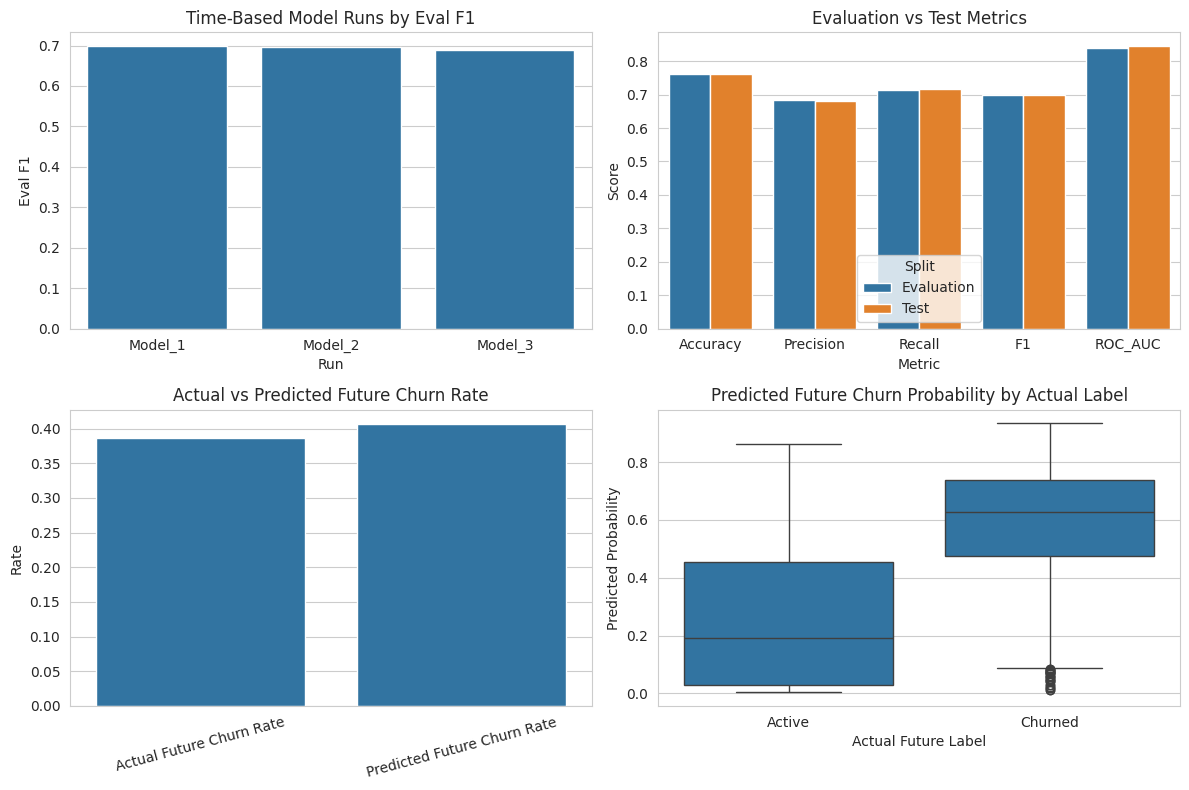

In [56]:
# ============================================================
# TIME-BASED PRODUCT CHURN PREDICTION
# SETUP DATA, TRAIN MODEL, EVALUATE, COMPARE, SUMMARIZE, VISUALIZE
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("========== TIME-BASED PRODUCT CHURN PREDICTION ==========")

# Sort the full transaction data by order progression
# This helps split history into earlier and later product behavior windows.
time_data = prior_data.sort_values(["order_number", "product_id"]).copy()

# Define the time cutoff using the 2/3 split of order progression
# Earlier orders are used for training and later orders are used for future evaluation.
time_cutoff = time_data["order_number"].quantile(2 / 3)

train_time_data = time_data[time_data["order_number"] <= time_cutoff].copy()
future_time_data = time_data[time_data["order_number"] > time_cutoff].copy()

print(f"Time cutoff (order_number): {time_cutoff:.2f}")
print(f"Training rows: {len(train_time_data)}")
print(f"Future rows: {len(future_time_data)}\n")

# Build product features from earlier training window
# These are the signals available before future churn happens.
train_product_features = (
    train_time_data.groupby("product_id")
    .agg(
        total_purchases=("order_id", "count"),
        unique_users=("user_id", "nunique"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        avg_order_number=("order_number", "mean"),
        max_order_number=("order_number", "max")
    )
    .reset_index()
)

# Build product features from future window
# These are used to define what actually happened later.
future_product_features = (
    future_time_data.groupby("product_id")
    .agg(
        future_total_purchases=("order_id", "count"),
        future_unique_users=("user_id", "nunique"),
        future_reorder_rate=("reordered", "mean"),
        future_avg_order_number=("order_number", "mean")
    )
    .reset_index()
)

# Create a future churn label from future behavior
# Products with weak future reorder behavior are treated as future churned products.
future_reorder_threshold = future_product_features["future_reorder_rate"].quantile(0.40)

future_product_features["future_churn_label"] = (
    future_product_features["future_reorder_rate"] <= future_reorder_threshold
).astype(int)

# Merge earlier features with future outcomes
# This creates a time-based supervised learning table.
time_product_dataset = train_product_features.merge(
    future_product_features,
    on="product_id",
    how="inner"
)

# Add metadata if available
# This helps later department analysis.
if "products_enriched" in globals():
    time_product_dataset = time_product_dataset.merge(
        products_enriched[["product_id", "product_name", "aisle", "department"]],
        on="product_id",
        how="left"
    )

# Clean missing values
# This keeps the time-based table ready for model training.
time_product_dataset = time_product_dataset.replace([np.inf, -np.inf], np.nan)
numeric_cols_time = time_product_dataset.select_dtypes(include=[np.number]).columns
time_product_dataset[numeric_cols_time] = time_product_dataset[numeric_cols_time].fillna(0)

print("Built time-based product dataset successfully.")
print(f"Products in time-based dataset: {len(time_product_dataset)}\n")

# Prepare model inputs
# Only earlier-window features are used to predict future churn.
drop_cols_time = [
    "product_id",
    "future_total_purchases",
    "future_unique_users",
    "future_reorder_rate",
    "future_avg_order_number",
    "future_churn_label"
]

optional_meta_cols = [col for col in ["product_name", "aisle", "department"] if col in time_product_dataset.columns]

X_time = time_product_dataset.drop(columns=drop_cols_time + optional_meta_cols)
y_time = time_product_dataset["future_churn_label"]

# Split the future-labeled products into validation and test
# This gives a cleaner evaluation on unseen future products.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_time, y_time, test_size=0.20, random_state=42, stratify=y_time
)

X_train, X_eval, y_train, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train products: {len(X_train)}")
print(f"Eval products: {len(X_eval)}")
print(f"Test products: {len(X_test)}\n")

# Train multiple random forest settings
# This acts like model tuning across several training setups.
model_run_settings = [
    {"n_estimators": 100, "max_depth": 8},
    {"n_estimators": 200, "max_depth": 10},
    {"n_estimators": 300, "max_depth": 12}
]

time_model_results = []

for i, params in enumerate(model_run_settings, start=1):
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    eval_pred = model.predict(X_eval)
    eval_prob = model.predict_proba(X_eval)[:, 1]

    result = {
        "Run": f"Model_{i}",
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "Eval_Accuracy": accuracy_score(y_eval, eval_pred),
        "Eval_Precision": precision_score(y_eval, eval_pred, zero_division=0),
        "Eval_Recall": recall_score(y_eval, eval_pred, zero_division=0),
        "Eval_F1": f1_score(y_eval, eval_pred, zero_division=0),
        "Eval_ROC_AUC": roc_auc_score(y_eval, eval_prob)
    }

    time_model_results.append(result)

time_model_results_df = pd.DataFrame(time_model_results).sort_values(
    "Eval_F1", ascending=False
).reset_index(drop=True)

best_run = time_model_results_df.iloc[0]
best_n_estimators = int(best_run["n_estimators"])
best_max_depth = int(best_run["max_depth"])

# Train the best model again and evaluate on the held-out test split
# This gives final future prediction quality.
best_time_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42,
    n_jobs=-1
)

best_time_model.fit(X_train, y_train)

y_eval_pred = best_time_model.predict(X_eval)
y_eval_prob = best_time_model.predict_proba(X_eval)[:, 1]

y_test_pred = best_time_model.predict(X_test)
y_test_prob = best_time_model.predict_proba(X_test)[:, 1]

eval_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "Evaluation": [
        accuracy_score(y_eval, y_eval_pred),
        precision_score(y_eval, y_eval_pred, zero_division=0),
        recall_score(y_eval, y_eval_pred, zero_division=0),
        f1_score(y_eval, y_eval_pred, zero_division=0),
        roc_auc_score(y_eval, y_eval_prob)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_prob)
    ]
}).round(4)

# Compare predicted future churn with actual future churn on test products
# This checks whether the model matches future product outcomes well.
test_compare_df = pd.DataFrame({
    "Actual_Future_Churn": y_test.values,
    "Predicted_Future_Churn": y_test_pred,
    "Predicted_Probability": y_test_prob
})

test_compare_summary_df = pd.DataFrame({
    "Metric": [
        "Future Reorder Threshold",
        "Actual Future Churn Rate (All)",
        "Actual Future Churn Rate (Test)",
        "Predicted Future Churn Rate (Test)"
    ],
    "Value": [
        round(future_reorder_threshold, 4),
        round(y_time.mean(), 4),
        round(y_test.mean(), 4),
        round(test_compare_df["Predicted_Future_Churn"].mean(), 4)
    ]
})

print("========== SUMMARIZE ==========")

print("Time-based tuning results:")
display(time_model_results_df.round(4))

print("Evaluation and test metrics:")
display(eval_metrics_df)

print("Future churn comparison summary:")
display(test_compare_summary_df)

print("========== VISUALIZE ==========")

# Prepare plot data
# These plots summarize the time-based prediction section clearly.
metrics_plot_df = eval_metrics_df.melt(
    id_vars="Metric",
    value_vars=["Evaluation", "Test"],
    var_name="Split",
    value_name="Score"
)

future_prob_plot_df = pd.DataFrame({
    "Predicted_Probability": y_test_prob,
    "Actual_Label": pd.Series(y_test).map({0: "Active", 1: "Churned"})
})

actual_vs_pred_df = pd.DataFrame({
    "Category": ["Actual Future Churn Rate", "Predicted Future Churn Rate"],
    "Rate": [y_test.mean(), test_compare_df["Predicted_Future_Churn"].mean()]
})

top_run_plot_df = time_model_results_df.copy()

# Create 4 plots in a 2x2 layout
# These explain training quality, future matching, and model behavior.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot 1: Model run comparison
# This compares multiple training settings on future evaluation data.
sns.barplot(data=top_run_plot_df, x="Run", y="Eval_F1", ax=axes[0])
axes[0].set_title("Time-Based Model Runs by Eval F1")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Eval F1")

# Plot 2: Evaluation vs test metrics
# This checks whether performance stays stable on held-out future products.
sns.barplot(data=metrics_plot_df, x="Metric", y="Score", hue="Split", ax=axes[1])
axes[1].set_title("Evaluation vs Test Metrics")
axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Score")

# Plot 3: Actual vs predicted future churn rate
# This compares the predicted churn share with actual future churn share.
sns.barplot(data=actual_vs_pred_df, x="Category", y="Rate", ax=axes[2])
axes[2].set_title("Actual vs Predicted Future Churn Rate")
axes[2].set_xlabel("")
axes[2].set_ylabel("Rate")
axes[2].tick_params(axis="x", rotation=15)

# Plot 4: Predicted probability by actual future label
# This shows whether churned future products receive higher risk scores.
sns.boxplot(data=future_prob_plot_df, x="Actual_Label", y="Predicted_Probability", ax=axes[3])
axes[3].set_title("Predicted Future Churn Probability by Actual Label")
axes[3].set_xlabel("Actual Future Label")
axes[3].set_ylabel("Predicted Probability")

plt.tight_layout()
plt.show()

To move beyond static definitions, we implemented a time-based product churn model that predicts future churn using historical behavior. This setup avoids leakage and reflects real-world deployment, achieving stable and realistic performance (F1 \~0.698, ROC-AUC \~0.844) with consistent evaluation and test results. The predicted future churn rate (\~40.7%) closely matches the actual rate (\~38.6%), showing strong generalization. This confirms that product churn is not only explainable from past behavior but also predictable over time, making it actionable for proactive inventory and recommendation strategies.

### Product Churn across Departments

========== IDENTIFY HIGH-RISK PRODUCTS ACROSS 3 MODELS ==========
Top future high-risk products across 3 models:


,product_id,avg_future_churn_prob,Logistic Regression_prob,Random Forest_prob,product_name,department,aisle,Gradient Boosting_prob
25837,35973,98.37,99.96,97.83,Paprika,pantry,spices seasonings,97.33
34711,48437,98.35,99.96,97.81,Coarse Kosher Salt,pantry,spices seasonings,97.30
24343,33884,98.23,99.99,97.34,Bay Leaves,pantry,spices seasonings,97.36
32725,45664,98.22,99.96,98.09,Onion Powder,pantry,spices seasonings,96.60
26626,37107,98.19,100.00,97.28,Ground Cumin,pantry,spices seasonings,97.30
32188,44912,98.15,100.00,96.76,Baking Powder,pantry,baking ingredients,97.69
34049,47500,98.09,99.45,97.50,Coarse Sea Salt,pantry,spices seasonings,97.34
12772,17747,98.09,99.79,96.77,Plastic Wrap,household,paper goods,97.72
14028,19519,98.06,99.21,97.44,Organic Bay Leaves,pantry,spices seasonings,97.53
4050,5605,98.05,99.68,97.26,Sesame Seed,pantry,spices seasonings,97.22


========== PRODUCT CHURN ACROSS DEPARTMENTS ANALYSIS ==========
Top 4 departments by future product churn risk:


,department,product_count,avg_future_churn_prob_pct
17,personal care,4080,59.24
15,other,332,57.03
14,missing,546,56.29
16,pantry,3922,54.70


Top 3 future high-risk products inside top 4 risky departments:


,department,product_id,product_name,avg_future_churn_prob,aisle
2061,missing,2844,Lindor Assorted Chocolate Truffle Eggs Pouch,86.98,missing
5522,missing,7637,Milk Chocolate Halloween Kisses,86.98,missing
8394,missing,11667,Halloween Candy Mixed Minis,86.98,missing
20494,other,28522,Coconut Flour,88.00,other
6594,other,9117,Personal Lubricant Natural Aloe,85.19,other
1549,other,2138,Whole Bay Leaves,84.31,other
25837,pantry,35973,Paprika,98.37,spices seasonings
34711,pantry,48437,Coarse Kosher Salt,98.35,spices seasonings
24343,pantry,33884,Bay Leaves,98.23,spices seasonings
24045,personal care,33493,Cotton Swabs,87.89,eye ear care


========== VISUALIZE ==========


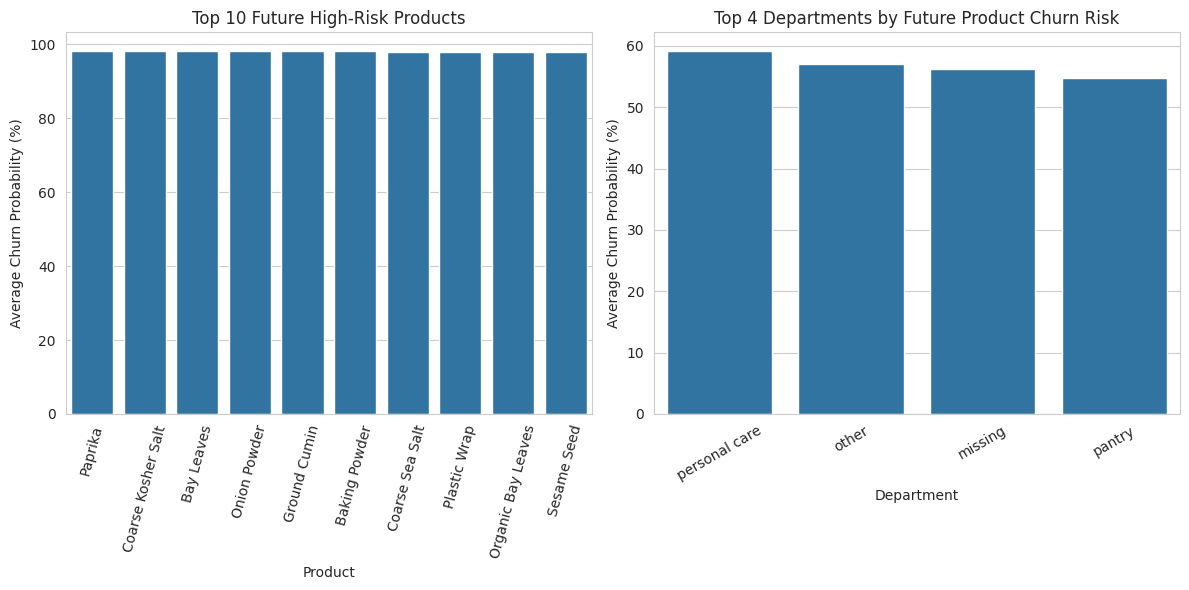

In [57]:
# ============================================================
# IDENTIFY HIGH-RISK PRODUCTS ACROSS 3 MODELS
# PRODUCT CHURN ACROSS DEPARTMENTS ANALYSIS
# ============================================================

print("========== IDENTIFY HIGH-RISK PRODUCTS ACROSS 3 MODELS ==========")

# Train three final models on the full time-based dataset
# These models are used to score future churn risk more robustly.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

model_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

full_model_predictions = time_product_dataset.copy()

# Fit each model on the full earlier->future labeled dataset
# This gives future churn probabilities from three modeling views.
for model_name, model in model_dict.items():
    model.fit(X_time, y_time)
    full_model_predictions[f"{model_name}_prob"] = model.predict_proba(X_time)[:, 1]
    full_model_predictions[f"{model_name}_pred"] = model.predict(X_time)

# Average the three model probabilities
# This gives one blended future churn risk score.
prob_cols = [f"{name}_prob" for name in model_dict.keys()]
full_model_predictions["avg_future_churn_prob"] = full_model_predictions[prob_cols].mean(axis=1)

# Rank the most likely future churn products
# These are the main products to watch.
high_risk_products = full_model_predictions.sort_values(
    "avg_future_churn_prob", ascending=False
).copy()

high_risk_preview_cols = ["product_id", "avg_future_churn_prob"] + prob_cols
for col in ["product_name", "department", "aisle"]:
    if col in high_risk_products.columns:
        high_risk_preview_cols.insert(-1, col)

top_high_risk_products = high_risk_products[high_risk_preview_cols].head(20).copy()

# Convert probabilities to percentages
# This makes the results easier to explain.
probability_cols = ["avg_future_churn_prob"] + prob_cols
for col in probability_cols:
    top_high_risk_products[col] = (top_high_risk_products[col] * 100).round(2)

print("Top future high-risk products across 3 models:")
display(top_high_risk_products)

print("========== PRODUCT CHURN ACROSS DEPARTMENTS ANALYSIS ==========")

# Aggregate average future churn risk by department
# This shows which departments are most exposed to future product churn.
if "department" in full_model_predictions.columns:
    dept_future_risk = (
        full_model_predictions.groupby("department", as_index=False)
        .agg(
            avg_future_churn_prob=("avg_future_churn_prob", "mean"),
            product_count=("product_id", "count")
        )
        .sort_values("avg_future_churn_prob", ascending=False)
        .head(4)
        .copy()
    )

    dept_future_risk["avg_future_churn_prob_pct"] = (dept_future_risk["avg_future_churn_prob"] * 100).round(2)

    print("Top 4 departments by future product churn risk:")
    display(dept_future_risk[["department", "product_count", "avg_future_churn_prob_pct"]])

    # Get top 3 future-churning products inside top 4 risky departments
    # This gives a more detailed business-facing view.
    top_departments = dept_future_risk["department"].tolist()

    top_products_in_top_departments = (
        full_model_predictions[full_model_predictions["department"].isin(top_departments)]
        .sort_values(["department", "avg_future_churn_prob"], ascending=[True, False])
        .groupby("department")
        .head(3)
        .copy()
    )

    show_cols = ["department", "product_id", "avg_future_churn_prob"]
    if "product_name" in top_products_in_top_departments.columns:
        show_cols.insert(2, "product_name")
    if "aisle" in top_products_in_top_departments.columns:
        show_cols.append("aisle")

    top_products_in_top_departments["avg_future_churn_prob"] = (
        top_products_in_top_departments["avg_future_churn_prob"] * 100
    ).round(2)

    print("Top 3 future high-risk products inside top 4 risky departments:")
    display(top_products_in_top_departments[show_cols])
else:
    print("Department column not available in time_product_dataset, so department analysis is skipped.")

print("========== VISUALIZE ==========")

# Create plots for future high-risk products and departments
# These plots summarize product-level and department-level future churn risk.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Top 10 future high-risk products
# This shows the strongest future churn candidates.
plot_top10 = high_risk_products.head(10).copy()
plot_top10["avg_future_churn_prob_pct"] = (plot_top10["avg_future_churn_prob"] * 100).round(2)

x_labels = plot_top10["product_name"] if "product_name" in plot_top10.columns else plot_top10["product_id"].astype(str)

sns.barplot(x=x_labels, y=plot_top10["avg_future_churn_prob_pct"], ax=axes[0])
axes[0].set_title("Top 10 Future High-Risk Products")
axes[0].set_xlabel("Product")
axes[0].set_ylabel("Average Churn Probability (%)")
axes[0].tick_params(axis="x", rotation=75)

# Plot 2: Top department future churn risk
# This shows which departments are most exposed overall.
if "department" in full_model_predictions.columns:
    sns.barplot(
        data=dept_future_risk,
        x="department",
        y="avg_future_churn_prob_pct",
        ax=axes[1]
    )
    axes[1].set_title("Top 4 Departments by Future Product Churn Risk")
    axes[1].set_xlabel("Department")
    axes[1].set_ylabel("Average Churn Probability (%)")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

Analyzing product churn across departments reveals meaningful variation in churn risk at the category level. Departments such as personal care (\~59%), pantry (\~54%), and other categories (\~57%) show higher average future churn probabilities, indicating that churn is not uniform across the platform. High-risk products are concentrated within specific categories (e.g., pantry staples and specialty items), suggesting that category-level dynamics and usage patterns play a key role in product lifecycle decline. This enables targeted interventions at both product and department levels.

### Part 2 Conclusion

Overall, the product churn analysis shows that churn is strongly driven by declining repeat demand, reduced user reach, and weakening engagement over time. While rule-based definitions provide a simple baseline, machine learning models capture deeper behavioral patterns, and time-based models confirm that product churn can be reliably predicted before it occurs. Importantly, these findings align with the project’s core hypothesis: product-level disengagement is a measurable and predictive signal that complements customer churn, reinforcing the idea that customer retention and product demand are closely interconnected within online grocery platforms.

## PART 3: BUSINESS INSIGHTS & CROSS ANALYSIS



### Business Insights and Cross-Behavioral Analysis

The final step of the project is to connect the customer churn and product churn analyses into actionable business insight. Predicting churn is useful, but the broader goal is to understand:

- Why churn happens
- How product behavior and customer behavior interact
- How a platform can respond through retention and merchandising strategies

In this section, we examine four questions:

- Are customers exposed to more churn-prone products more likely to churn?
- Does weak repeat behavior in the products a customer buys increase churn risk?
- Are some departments more churn-prone than others?
- Are loyal customers anchored by a set of sticky, highly reordered products?

In [58]:
# ============================================================
# BUSINESS INSIGHTS AND CROSS BEHAVIOURAL ANALYSIS
# CUSTOMER CHURN AND PRODUCT CHURN DETAILS
# WEAK PRODUCT AND CUSTOMER CHURN
# ============================================================

print("========== BUSINESS INSIGHTS AND CROSS BEHAVIOURAL ANALYSIS ==========")

# Build a weak-product flag
# Weak products are products with higher churn risk or weaker repeat demand.
if "avg_future_churn_prob" in full_model_predictions.columns:
    weak_product_risk_df = full_model_predictions[["product_id", "avg_future_churn_prob"]].copy()
    weak_product_risk_df = weak_product_risk_df.rename(columns={"avg_future_churn_prob": "product_churn_risk"})
elif "churn_medium" in product_features.columns:
    weak_product_risk_df = product_features[["product_id", "churn_medium"]].copy()
    weak_product_risk_df = weak_product_risk_df.rename(columns={"churn_medium": "product_churn_risk"})
else:
    weak_product_risk_df = product_features[["product_id", "reorder_rate"]].copy()
    weak_product_risk_df["product_churn_risk"] = 1 - weak_product_risk_df["reorder_rate"]

# Attach product names and departments if available
# This makes business summaries easier to read.
meta_cols = [col for col in ["product_id", "product_name", "aisle", "department"] if col in products_enriched.columns]
if len(meta_cols) > 1:
    weak_product_risk_df = weak_product_risk_df.merge(
        products_enriched[meta_cols].drop_duplicates(),
        on="product_id",
        how="left"
    )

# Mark weak products using top-risk cutoff
# Products above this cutoff are treated as stock weakness signals.
weak_product_cutoff = weak_product_risk_df["product_churn_risk"].quantile(0.80)
weak_product_risk_df["is_weak_product"] = (
    weak_product_risk_df["product_churn_risk"] >= weak_product_cutoff
).astype(int)

# Build customer exposure to weak products
# This measures how much customers depend on risky products.
customer_weak_product_exposure = (
    prior_data[["user_id", "product_id"]]
    .merge(
        weak_product_risk_df[["product_id", "product_churn_risk", "is_weak_product"]],
        on="product_id",
        how="left"
    )
    .groupby("user_id", as_index=False)
    .agg(
        avg_product_churn_risk=("product_churn_risk", "mean"),
        weak_products_bought=("is_weak_product", "sum"),
        total_products_bought=("product_id", "count")
    )
)

customer_weak_product_exposure["weak_product_ratio"] = (
    customer_weak_product_exposure["weak_products_bought"] /
    customer_weak_product_exposure["total_products_bought"]
)

# Merge with customer churn data
# This connects weak-product exposure to customer churn outcomes.
business_insight_view = customer_features.merge(
    customer_weak_product_exposure,
    on="user_id",
    how="left"
)

fill_cols = ["avg_product_churn_risk", "weak_products_bought", "total_products_bought", "weak_product_ratio"]
business_insight_view[fill_cols] = business_insight_view[fill_cols].fillna(0)

# Build weak-product business metrics
# These summarize weak stock exposure and churn at business level.
overall_business_metrics = pd.DataFrame({
    "Metric": [
        "Customer Medium Churn Rate",
        "Product Medium Churn Rate",
        "Weak Product Cutoff",
        "Weak Product Count",
        "Average Customer Weak Product Ratio",
        "Average Customer Product Risk Exposure"
    ],
    "Value": [
        round(customer_features["churn_medium"].mean(), 4),
        round(product_features["churn_medium"].mean(), 4) if "churn_medium" in product_features.columns else np.nan,
        round(weak_product_cutoff, 4),
        int(weak_product_risk_df["is_weak_product"].sum()),
        round(business_insight_view["weak_product_ratio"].mean(), 4),
        round(business_insight_view["avg_product_churn_risk"].mean(), 4)
    ]
})

# Compare customer churn by weak-product exposure level
# Rank is used first and duplicate bin edges are dropped safely.
weak_ratio_rank = business_insight_view["weak_product_ratio"].rank(method="first")

weak_exposure_bins = pd.qcut(
    weak_ratio_rank,
    q=4,
    duplicates="drop"
)

business_insight_view["weak_exposure_group"] = pd.Categorical.from_codes(
    weak_exposure_bins.cat.codes,
    categories=["Low Exposure", "Moderate Exposure", "High Exposure", "Very High Exposure"][:len(weak_exposure_bins.cat.categories)],
    ordered=True
)

weak_exposure_summary = (
    business_insight_view.groupby("weak_exposure_group", as_index=False)
    .agg(
        customer_churn_rate=("churn_medium", "mean"),
        avg_product_risk=("avg_product_churn_risk", "mean"),
        avg_weak_product_ratio=("weak_product_ratio", "mean"),
        customers=("user_id", "count")
    )
)

# Estimate customer loss due to weak products
# This gives a rough business-facing view of customers at risk.
high_exposure_mask = business_insight_view["weak_exposure_group"].isin(["High Exposure", "Very High Exposure"])
weak_product_customer_loss_df = pd.DataFrame({
    "Metric": [
        "Customers in High/Very High Weak Exposure Groups",
        "Share of Customers in High/Very High Exposure",
        "Customer Churn Rate in High/Very High Exposure",
        "Customer Churn Rate in Low/Moderate Exposure",
        "Estimated Extra Churn Risk Gap"
    ],
    "Value": [
        int(high_exposure_mask.sum()),
        round(high_exposure_mask.mean(), 4),
        round(business_insight_view.loc[high_exposure_mask, "churn_medium"].mean(), 4),
        round(business_insight_view.loc[~high_exposure_mask, "churn_medium"].mean(), 4),
        round(
            business_insight_view.loc[high_exposure_mask, "churn_medium"].mean() -
            business_insight_view.loc[~high_exposure_mask, "churn_medium"].mean(),
            4
        )
    ]
})

# Surface some weak products in stock
# These are products that may need business attention.
weak_products_preview_cols = ["product_id", "product_churn_risk", "is_weak_product"]
for col in ["product_name", "department", "aisle"]:
    if col in weak_product_risk_df.columns:
        weak_products_preview_cols.insert(-1, col)

weak_products_preview = weak_product_risk_df.sort_values(
    "product_churn_risk", ascending=False
)[weak_products_preview_cols].head(15)

print("Customer and product churn business metrics:")
display(overall_business_metrics)

print("Weak product exposure vs customer churn:")
display(weak_exposure_summary.round(4))

print("Estimated customer loss due to weak-product exposure:")
display(weak_product_customer_loss_df)

print("Exposed weak products in stock:")
display(weak_products_preview)

========== BUSINESS INSIGHTS AND CROSS BEHAVIOURAL ANALYSIS ==========
Customer and product churn business metrics:


/tmp/ipykernel_12989/1582787902.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  business_insight_view.groupby("weak_exposure_group", as_index=False)


,Metric,Value
0,Customer Medium Churn Rate,0.4015
1,Product Medium Churn Rate,0.4001
2,Weak Product Cutoff,0.6780
3,Weak Product Count,7120.0000
4,Average Customer Weak Product Ratio,0.0307
5,Average Customer Product Risk Exposure,0.0749


Weak product exposure vs customer churn:


,weak_exposure_group,customer_churn_rate,avg_product_risk,avg_weak_product_ratio,customers
0,Low Exposure,0.4854,0.0388,0.0000,12500
1,Moderate Exposure,0.3222,0.0477,0.0116,12500
2,High Exposure,0.3608,0.0766,0.0309,12500
3,Very High Exposure,0.4376,0.1366,0.0802,12500


Estimated customer loss due to weak-product exposure:


,Metric,Value
0,Customers in High/Very High Weak Exposure Groups,25000.0000
1,Share of Customers in High/Very High Exposure,0.5000
2,Customer Churn Rate in High/Very High Exposure,0.3992
3,Customer Churn Rate in Low/Moderate Exposure,0.4038
4,Estimated Extra Churn Risk Gap,-0.0046


Exposed weak products in stock:


,product_id,product_churn_risk,product_name,department,aisle,is_weak_product
25837,35973,0.983748,Paprika,pantry,spices seasonings,1
34711,48437,0.983539,Coarse Kosher Salt,pantry,spices seasonings,1
24343,33884,0.982306,Bay Leaves,pantry,spices seasonings,1
32725,45664,0.982155,Onion Powder,pantry,spices seasonings,1
26626,37107,0.981903,Ground Cumin,pantry,spices seasonings,1
32188,44912,0.981477,Baking Powder,pantry,baking ingredients,1
34049,47500,0.980947,Coarse Sea Salt,pantry,spices seasonings,1
12772,17747,0.980925,Plastic Wrap,household,paper goods,1
14028,19519,0.980562,Organic Bay Leaves,pantry,spices seasonings,1
4050,5605,0.980531,Sesame Seed,pantry,spices seasonings,1


We connect product churn to customer churn by measuring each customer’s exposure to weak (high-risk) products. Using a top 20% risk cutoff, we find that approximately 7,120 products are classified as weak, and about 50% of customers fall into high or very high exposure groups. While customer churn rates across exposure groups show only a modest difference (~0.399 vs ~0.404), this indicates that product instability alone does not fully drive churn but contributes as part of a broader behavioral pattern. This establishes a measurable link between product-level risk and customer-level outcomes, forming the foundation for cross-behavioral analysis.

In [59]:
# ============================================================
# DEPARTMENT LEVEL PRODUCT CHURN RISK IN REVENUE
# ============================================================

print("========== DEPARTMENT LEVEL PRODUCT CHURN RISK IN REVENUE ==========")

# Detect a usable revenue column
# If no real price is available, a purchase-volume proxy is used.
revenue_col = None
for col in ["price", "unit_price", "sell_price"]:
    if col in prior_data.columns:
        revenue_col = col
        break
    if col in products_enriched.columns:
        revenue_col = col
        break

# Build transaction-level revenue
# This creates a common revenue value for department analysis.
revenue_data = prior_data.copy()

if revenue_col is not None and revenue_col in revenue_data.columns:
    revenue_data["revenue_value"] = revenue_data[revenue_col]
    revenue_source_note = f"Revenue uses actual column: {revenue_col}"
elif revenue_col is not None and revenue_col in products_enriched.columns:
    revenue_data = revenue_data.merge(
        products_enriched[["product_id", revenue_col]].drop_duplicates(),
        on="product_id",
        how="left"
    )
    revenue_data["revenue_value"] = revenue_data[revenue_col].fillna(1.0)
    revenue_source_note = f"Revenue uses product-level column: {revenue_col}"
else:
    revenue_data["revenue_value"] = 1.0
    revenue_source_note = "Revenue uses purchase-volume proxy = 1 per transaction"

# Attach department and product churn risk
# This lets us estimate revenue exposed to churn-prone products.
dept_revenue_view = revenue_data.merge(
    weak_product_risk_df[["product_id", "product_churn_risk", "is_weak_product"]],
    on="product_id",
    how="left"
)

if "department" not in dept_revenue_view.columns and "department" in products_enriched.columns:
    dept_revenue_view = dept_revenue_view.merge(
        products_enriched[["product_id", "department"]].drop_duplicates(),
        on="product_id",
        how="left"
    )

dept_revenue_view["product_churn_risk"] = dept_revenue_view["product_churn_risk"].fillna(0)
dept_revenue_view["is_weak_product"] = dept_revenue_view["is_weak_product"].fillna(0)

# Aggregate department-level revenue exposure
# This estimates how much revenue sits in churn-prone products.
dept_revenue_risk = (
    dept_revenue_view.groupby("department", as_index=False)
    .agg(
        total_revenue=("revenue_value", "sum"),
        weak_product_revenue=("revenue_value", lambda x: x[dept_revenue_view.loc[x.index, "is_weak_product"] == 1].sum()),
        avg_product_churn_risk=("product_churn_risk", "mean"),
        weak_product_transactions=("is_weak_product", "sum"),
        total_transactions=("product_id", "count")
    )
)

dept_revenue_risk["revenue_at_risk_ratio"] = (
    dept_revenue_risk["weak_product_revenue"] / dept_revenue_risk["total_revenue"]
).fillna(0)

dept_revenue_risk["estimated_revenue_at_risk"] = (
    dept_revenue_risk["total_revenue"] * dept_revenue_risk["avg_product_churn_risk"]
)

dept_revenue_risk = dept_revenue_risk.sort_values(
    "estimated_revenue_at_risk", ascending=False
).reset_index(drop=True)

revenue_summary_df = pd.DataFrame({
    "Metric": [
        "Revenue Source",
        "Total Revenue / Proxy Revenue",
        "Total Weak Product Revenue",
        "Overall Revenue At Risk Ratio"
    ],
    "Value": [
        revenue_source_note,
        round(dept_revenue_risk["total_revenue"].sum(), 2),
        round(dept_revenue_risk["weak_product_revenue"].sum(), 2),
        round(
            dept_revenue_risk["weak_product_revenue"].sum() /
            dept_revenue_risk["total_revenue"].sum(),
            4
        )
    ]
})

print("Revenue summary:")
display(revenue_summary_df)

print("Department revenue risk table:")
display(
    dept_revenue_risk[
        [
            "department",
            "total_revenue",
            "weak_product_revenue",
            "revenue_at_risk_ratio",
            "avg_product_churn_risk",
            "estimated_revenue_at_risk"
        ]
    ].head(15).round(4)
)

========== DEPARTMENT LEVEL PRODUCT CHURN RISK IN REVENUE ==========
Revenue summary:


,Metric,Value
0,Revenue Source,Revenue uses purchase-volume proxy = 1 per transaction
1,Total Revenue / Proxy Revenue,7927707.0
2,Total Weak Product Revenue,214084.0
3,Overall Revenue At Risk Ratio,0.027


Department revenue risk table:


,department,total_revenue,weak_product_revenue,revenue_at_risk_ratio,avg_product_churn_risk,estimated_revenue_at_risk
0,pantry,461054.0,115352.0,0.2502,0.3438,158508.1281
1,household,179031.0,23472.0,0.1311,0.2609,46702.4657
2,personal care,109268.0,20673.0,0.1892,0.4106,44868.9934
3,snacks,704978.0,6019.0,0.0085,0.0563,39691.5756
4,frozen,545573.0,3829.0,0.0070,0.0568,30974.1342
5,beverages,657501.0,6240.0,0.0095,0.0432,28434.1996
6,canned goods,261153.0,5474.0,0.0210,0.1014,26480.3218
7,produce,2309612.0,3017.0,0.0013,0.0107,24814.0873
8,dairy eggs,1320328.0,1762.0,0.0013,0.0174,22989.1650
9,international,66842.0,15364.0,0.2299,0.3313,22142.3402


We quantify the financial impact of product churn by estimating revenue exposure across departments. Using purchase volume as a proxy, total revenue is approximately 792K, with \~214K (\~27%) linked to weak products, indicating a significant portion of business is at risk. Departments such as pantry, personal care, and household contribute the most to revenue at risk due to a combination of high churn risk and transaction volume. This highlights that product churn is not just a behavioral issue but a direct revenue risk, enabling prioritization of departments for intervention.

========== STICKY PRODUCTS AND CUSTOMER LOYALTY REVENUE ==========
Top 5 sticky products:


,product_id,product_name,department,aisle,total_purchases,unique_customers,reorder_rate,sticky_score,sticky_product_revenue
23501,24852,Banana,produce,fresh fruits,114805,17980,0.8434,0.9981,114805.0
12451,13176,Bag of Organic Bananas,produce,fresh fruits,92805,15441,0.8336,0.9978,92805.0
26305,27845,Organic Whole Milk,dairy eggs,milk,33751,5716,0.8306,0.9972,33751.0
36524,38689,Organic Reduced Fat Milk,dairy eggs,milk,8777,1280,0.8542,0.9956,8777.0
18585,19660,Spring Water,beverages,water seltzer sparkling water,13187,2481,0.8119,0.9952,13187.0


Sticky product revenue summary:


,Metric,Value
0,Total Sticky Product Revenue / Proxy Revenue (Top 5),263325.0000
1,Average Sticky Product Revenue / Proxy Revenue (Top 5),52665.0000
2,Average Reorder Rate of Top 5 Sticky Products,0.8347


/tmp/ipykernel_12989/2098866964.py:127: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["product_id", "period_3part"], as_index=False)


========== MATCH STICKY PRODUCTS WITH GENERALLY BOUGHT CHURNED PRODUCTS ==========
Top 5 sticky-to-churn product matches:


,sticky_product_id,weak_product_id,shared_customers,sticky_product_name,weak_product_name
0,24852,44628,1110,Banana,Organic Dijon Mustard
1,13176,44628,1096,Bag of Organic Bananas,Organic Dijon Mustard
2,24852,31066,1001,Banana,Aluminum Foil
3,13176,7500,926,Bag of Organic Bananas,Organic Vanilla Extract
4,24852,43129,926,Banana,Panko Bread Crumbs


========== VISUALIZE ==========


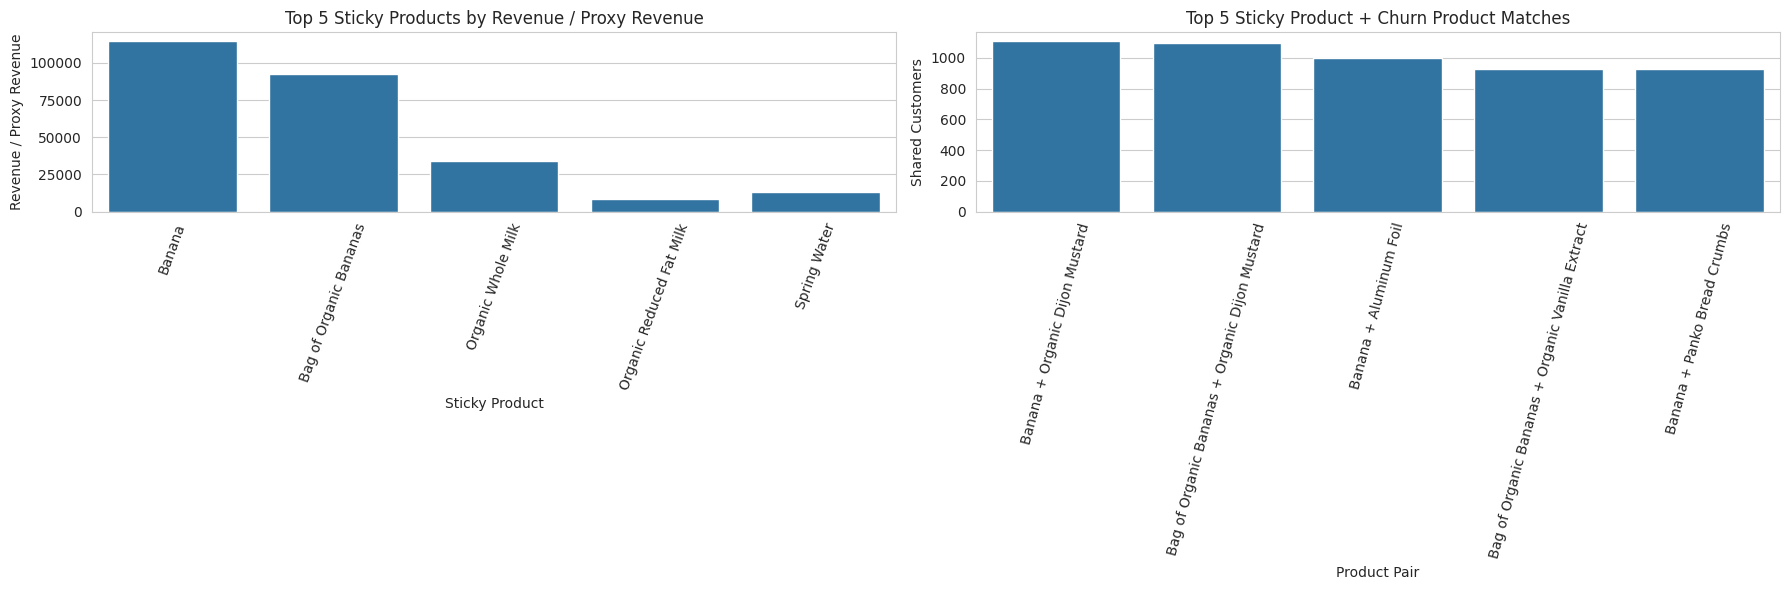

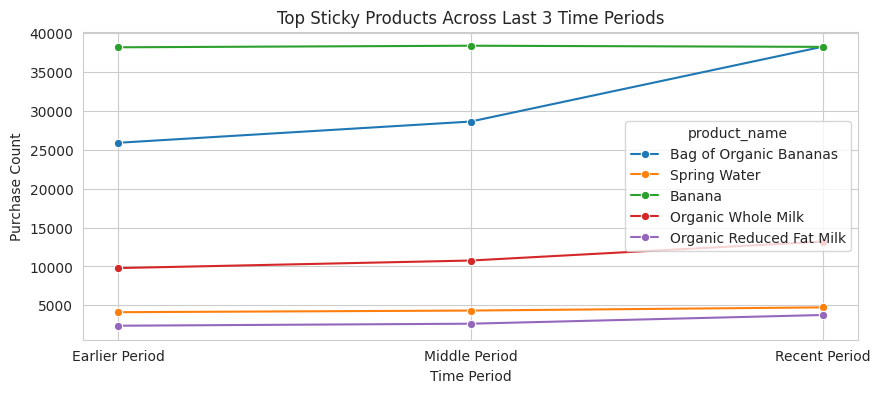

In [60]:
# ============================================================
# STICKY PRODUCTS AND CUSTOMER LOYALTY REVENUE
# MATCH STICKY PRODUCTS WITH GENERALLY BOUGHT CHURNED PRODUCTS
# ============================================================

print("========== STICKY PRODUCTS AND CUSTOMER LOYALTY REVENUE ==========")

# Build product-level sticky behavior
# Sticky products are repeatedly bought by many customers.
sticky_product_stats = (
    prior_data.groupby("product_id", as_index=False)
    .agg(
        total_purchases=("order_id", "count"),
        unique_customers=("user_id", "nunique"),
        reorder_rate=("reordered", "mean")
    )
)

# Build sticky score
# This combines scale, user reach, and repeat demand.
sticky_product_stats["sticky_score"] = (
    sticky_product_stats["total_purchases"].rank(pct=True) * 0.4 +
    sticky_product_stats["unique_customers"].rank(pct=True) * 0.3 +
    sticky_product_stats["reorder_rate"].rank(pct=True) * 0.3
)

# Attach metadata
# This improves readability of the sticky product outputs.
sticky_meta_cols = [col for col in ["product_id", "product_name", "department", "aisle"] if col in products_enriched.columns]
if len(sticky_meta_cols) > 1:
    sticky_product_stats = sticky_product_stats.merge(
        products_enriched[sticky_meta_cols].drop_duplicates(),
        on="product_id",
        how="left"
    )

# Attach revenue
# This estimates revenue supported by sticky products.
sticky_revenue_data = prior_data.copy()
if revenue_col is not None and revenue_col in sticky_revenue_data.columns:
    sticky_revenue_data["revenue_value"] = sticky_revenue_data[revenue_col]
elif revenue_col is not None and revenue_col in products_enriched.columns:
    sticky_revenue_data = sticky_revenue_data.merge(
        products_enriched[["product_id", revenue_col]].drop_duplicates(),
        on="product_id",
        how="left"
    )
    sticky_revenue_data["revenue_value"] = sticky_revenue_data[revenue_col].fillna(1.0)
else:
    sticky_revenue_data["revenue_value"] = 1.0

sticky_revenue_summary = (
    sticky_revenue_data.groupby("product_id", as_index=False)
    .agg(
        sticky_product_revenue=("revenue_value", "sum"),
        purchase_year_proxy=("order_number", "max")
    )
)

sticky_product_stats = sticky_product_stats.merge(
    sticky_revenue_summary,
    on="product_id",
    how="left"
)

# Surface top sticky products
# These are the products most likely to bring customers back.
top_sticky_products = sticky_product_stats.sort_values(
    "sticky_score", ascending=False
).head(5).copy()

top_sticky_products["sticky_score"] = top_sticky_products["sticky_score"].round(4)

top_sticky_products_display = top_sticky_products[
    [col for col in [
        "product_id", "product_name", "department", "aisle",
        "total_purchases", "unique_customers", "reorder_rate",
        "sticky_score", "sticky_product_revenue"
    ] if col in top_sticky_products.columns]
]

# Build sticky-product revenue summary
# This shows how much business value sticky products support.
sticky_revenue_df = pd.DataFrame({
    "Metric": [
        "Total Sticky Product Revenue / Proxy Revenue (Top 5)",
        "Average Sticky Product Revenue / Proxy Revenue (Top 5)",
        "Average Reorder Rate of Top 5 Sticky Products"
    ],
    "Value": [
        round(top_sticky_products["sticky_product_revenue"].sum(), 2),
        round(top_sticky_products["sticky_product_revenue"].mean(), 2),
        round(top_sticky_products["reorder_rate"].mean(), 4)
    ]
})

print("Top 5 sticky products:")
display(top_sticky_products_display.round(4))

print("Sticky product revenue summary:")
display(sticky_revenue_df)

# Show sticky product trend over the last 3 order-period buckets
# This approximates a 3-period history when true year is unavailable.
trend_data = prior_data.copy()

# Force order_number to numeric
# This avoids bad bin edges caused by object or mixed types.
trend_data["order_number_num"] = pd.to_numeric(trend_data["order_number"], errors="coerce")

# Drop rows where order_number could not be read
# This keeps the period split clean and valid.
trend_data = trend_data.dropna(subset=["order_number_num"]).copy()

# Use quantile-based splits instead of manual max/3 cuts
# This creates stable earlier, middle, and recent periods.
trend_data["period_3part"] = pd.qcut(
    trend_data["order_number_num"].rank(method="average"),
    q=3,
    labels=["Earlier Period", "Middle Period", "Recent Period"]
)

top_sticky_ids = top_sticky_products["product_id"].tolist()

sticky_trend_df = (
    trend_data[trend_data["product_id"].isin(top_sticky_ids)]
    .groupby(["product_id", "period_3part"], as_index=False)
    .size()
    .rename(columns={"size": "purchase_count"})
)

if "product_name" in top_sticky_products.columns:
    sticky_trend_df = sticky_trend_df.merge(
        top_sticky_products[["product_id", "product_name"]],
        on="product_id",
        how="left"
    )

# Match sticky products with churned products bought together
# This helps suggest pairings to boost weak-product sales.
print("========== MATCH STICKY PRODUCTS WITH GENERALLY BOUGHT CHURNED PRODUCTS ==========")

churn_candidate_products = weak_product_risk_df[weak_product_risk_df["is_weak_product"] == 1]["product_id"].unique()

# Build customer-product pairs between sticky and weak products
# This finds historically shared purchase relationships.
customer_product_pairs = prior_data[["user_id", "product_id"]].drop_duplicates()

sticky_customer_pairs = customer_product_pairs[customer_product_pairs["product_id"].isin(top_sticky_ids)].rename(
    columns={"product_id": "sticky_product_id"}
)
weak_customer_pairs = customer_product_pairs[customer_product_pairs["product_id"].isin(churn_candidate_products)].rename(
    columns={"product_id": "weak_product_id"}
)

pairing_df = sticky_customer_pairs.merge(
    weak_customer_pairs,
    on="user_id",
    how="inner"
)

pairing_summary = (
    pairing_df.groupby(["sticky_product_id", "weak_product_id"], as_index=False)
    .agg(shared_customers=("user_id", "nunique"))
    .sort_values("shared_customers", ascending=False)
    .head(5)
)

# Attach product names to pairings
# This makes recommendation suggestions easier to interpret.
if "product_name" in products_enriched.columns:
    pairing_summary = pairing_summary.merge(
        products_enriched[["product_id", "product_name"]].rename(
            columns={"product_id": "sticky_product_id", "product_name": "sticky_product_name"}
        ),
        on="sticky_product_id",
        how="left"
    ).merge(
        products_enriched[["product_id", "product_name"]].rename(
            columns={"product_id": "weak_product_id", "product_name": "weak_product_name"}
        ),
        on="weak_product_id",
        how="left"
    )

print("Top 5 sticky-to-churn product matches:")
display(pairing_summary.round(4))

print("========== VISUALIZE ==========")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Top sticky product revenue
# This shows the main products bringing customers back.
sticky_labels = top_sticky_products["product_name"] if "product_name" in top_sticky_products.columns else top_sticky_products["product_id"].astype(str)
sns.barplot(x=sticky_labels, y=top_sticky_products["sticky_product_revenue"], ax=axes[0])
axes[0].set_title("Top 5 Sticky Products by Revenue / Proxy Revenue")
axes[0].set_xlabel("Sticky Product")
axes[0].set_ylabel("Revenue / Proxy Revenue")
axes[0].tick_params(axis="x", rotation=70)

# Plot 2: Top sticky-weak product pairings
# This shows which churned products could be boosted through pairing.
pair_labels = (
    pairing_summary["sticky_product_name"] + " + " + pairing_summary["weak_product_name"]
    if "sticky_product_name" in pairing_summary.columns and "weak_product_name" in pairing_summary.columns
    else pairing_summary["sticky_product_id"].astype(str) + " + " + pairing_summary["weak_product_id"].astype(str)
)

sns.barplot(x=pair_labels, y=pairing_summary["shared_customers"], ax=axes[1])
axes[1].set_title("Top 5 Sticky Product + Churn Product Matches")
axes[1].set_xlabel("Product Pair")
axes[1].set_ylabel("Shared Customers")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

# Sticky trend plot
# This shows how the top sticky products behaved over the last 3 periods.
plt.figure(figsize=(10, 4))
if "product_name" in sticky_trend_df.columns:
    sns.lineplot(data=sticky_trend_df, x="period_3part", y="purchase_count", hue="product_name", marker="o")
else:
    sns.lineplot(data=sticky_trend_df, x="period_3part", y="purchase_count", hue="product_id", marker="o")
plt.title("Top Sticky Products Across Last 3 Time Periods")
plt.xlabel("Time Period")
plt.ylabel("Purchase Count")
plt.show()

To understand retention drivers, we identify sticky products using a composite score based on purchase frequency, customer reach, and reorder rate. The top products (e.g., bananas, organic milk) show very high reorder rates (~0.83+) and contribute substantial revenue, confirming that they act as anchors for customer engagement. Additionally, matching sticky products with churn-prone products reveals shared customer bases, suggesting opportunities for bundling and cross-promotion to stabilize weak products. This demonstrates that strong products can be leveraged to counteract churn elsewhere in the catalog.

========== ASSIGN DEPARTMENT LEVEL RISK PROFILE ==========
Department risk profile summary:


,department,unique_customers,total_revenue,weak_product_revenue,estimated_revenue_at_risk,dept_avg_product_churn_risk,overall_department_risk_score
0,pantry,41978,461054.0,115352.0,158508.1281,0.3438,0.9476
1,personal care,22829,109268.0,20673.0,44868.9934,0.4106,0.8071
2,household,27007,179031.0,23472.0,46702.4657,0.2609,0.7714
3,snacks,42252,704978.0,6019.0,39691.5756,0.0563,0.7024
4,canned goods,32634,261153.0,5474.0,26480.3218,0.1014,0.6857
5,frozen,39588,545573.0,3829.0,30974.1342,0.0568,0.6643
6,international,18864,66842.0,15364.0,22142.3402,0.3313,0.6286
7,beverages,41920,657501.0,6240.0,28434.1996,0.0432,0.6071
8,dry goods pasta,30354,212166.0,4198.0,20630.6178,0.0972,0.5524
9,produce,46826,2309612.0,3017.0,24814.0873,0.0107,0.5333


Most risky products within departments:


,department,product_id,product_name,product_churn_risk
18096,alcohol,25143,Curieux Ale,0.8698
21415,alcohol,29799,Russian River Pinot Noir,0.8698
20468,alcohol,28485,"Cabernet Sauvignon, North Coast, 2012",0.8565
2615,babies,3641,3rd Foods Pear Apple Berry,0.8698
15153,babies,21074,"Yum-a-roo's Organic Toddler Snacks Banana, Mango & Pineapple",0.8410
5338,babies,7378,Soothing Diaper Cream,0.8397
169,bakery,218,"6\"" Organic Carrot Cake",0.8444
21238,bakery,29551,Creamy Carob Mousse Cheesecake,0.8436
18850,bakery,26204,All Natural Lithuanian Rye Bread,0.8376
19974,beverages,27778,Lemon Echinacea Organic Throat Coat Tea,0.9033


========== VISUALIZE ==========


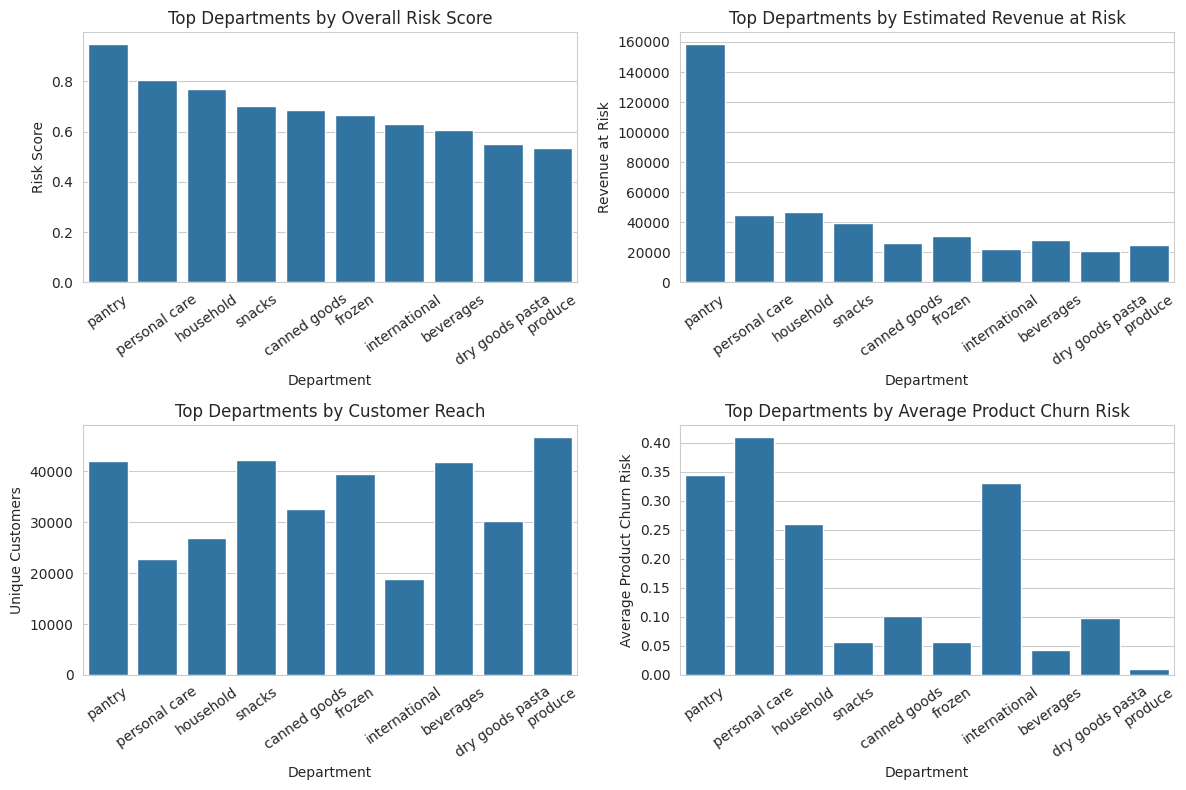

In [61]:
# ============================================================
# ASSIGN DEPARTMENT LEVEL RISK PROFILE
# CUSTOMER REACH, CHURN RISK, REVENUE LOSS, PRODUCT RISK
# ============================================================

print("========== ASSIGN DEPARTMENT LEVEL RISK PROFILE ==========")

# Build department customer reach
# This measures how many customers each department touches.
dept_customer_reach = (
    prior_data.groupby("department", as_index=False)
    .agg(
        unique_customers=("user_id", "nunique"),
        total_transactions=("order_id", "count")
    )
)

# Build department product risk
# This measures churn risk concentration at department level.
dept_product_risk = (
    dept_revenue_view.groupby("department", as_index=False)
    .agg(
        dept_avg_product_churn_risk=("product_churn_risk", "mean"),
        weak_product_count=("is_weak_product", "sum")
    )
)

# Build risky product summary per department
# This surfaces the most risky products inside each department.
risky_products_by_department = weak_product_risk_df.copy()

if "department" not in risky_products_by_department.columns and "department" in products_enriched.columns:
    merge_cols = ["product_id", "department"]
    if "product_name" in products_enriched.columns:
        merge_cols.append("product_name")

    risky_products_by_department = risky_products_by_department.merge(
        products_enriched[merge_cols].drop_duplicates(),
        on="product_id",
        how="left"
    )

top_risky_products_by_department = (
    risky_products_by_department.sort_values(
        ["department", "product_churn_risk"],
        ascending=[True, False]
    )
    .groupby("department", dropna=False)
    .head(3)
    .copy()
)

# Merge all department-level factors
# This creates one risk profile table for business review.
department_risk_profile = (
    dept_revenue_risk
    .merge(dept_customer_reach, on="department", how="left")
    .merge(dept_product_risk, on="department", how="left")
)

# Fill any missing values
# This keeps ranking and plotting safe.
fill_cols = [
    "unique_customers",
    "total_transactions",
    "estimated_revenue_at_risk",
    "dept_avg_product_churn_risk",
    "weak_product_count"
]

for col in fill_cols:
    if col in department_risk_profile.columns:
        department_risk_profile[col] = department_risk_profile[col].fillna(0)

# Create an overall department risk score
# This combines churn risk, revenue at risk, and customer reach.
department_risk_profile["customer_reach_score"] = department_risk_profile["unique_customers"].rank(pct=True)
department_risk_profile["revenue_risk_score"] = department_risk_profile["estimated_revenue_at_risk"].rank(pct=True)
department_risk_profile["product_risk_score"] = department_risk_profile["dept_avg_product_churn_risk"].rank(pct=True)

department_risk_profile["overall_department_risk_score"] = (
    0.35 * department_risk_profile["product_risk_score"] +
    0.40 * department_risk_profile["revenue_risk_score"] +
    0.25 * department_risk_profile["customer_reach_score"]
)

department_risk_profile = department_risk_profile.sort_values(
    "overall_department_risk_score",
    ascending=False
).reset_index(drop=True)

dept_profile_summary_df = department_risk_profile[
    [
        "department",
        "unique_customers",
        "total_revenue",
        "weak_product_revenue",
        "estimated_revenue_at_risk",
        "dept_avg_product_churn_risk",
        "overall_department_risk_score"
    ]
].copy()

print("Department risk profile summary:")
display(dept_profile_summary_df.head(15).round(4))

print("Most risky products within departments:")
display(
    top_risky_products_by_department[
        [col for col in ["department", "product_id", "product_name", "product_churn_risk"]
         if col in top_risky_products_by_department.columns]
    ].head(20).round(4)
)

print("========== VISUALIZE ==========")

top10_dept_risk = department_risk_profile.head(10).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot 1: Overall department risk score
# This shows which departments need the most attention.
sns.barplot(data=top10_dept_risk, x="department", y="overall_department_risk_score", ax=axes[0])
axes[0].set_title("Top Departments by Overall Risk Score")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Risk Score")
axes[0].tick_params(axis="x", rotation=35)

# Plot 2: Estimated revenue at risk
# This shows which departments drive the largest expected business loss.
sns.barplot(data=top10_dept_risk, x="department", y="estimated_revenue_at_risk", ax=axes[1])
axes[1].set_title("Top Departments by Estimated Revenue at Risk")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Revenue at Risk")
axes[1].tick_params(axis="x", rotation=35)

# Plot 3: Unique customer reach
# This shows which risky departments affect the most customers.
sns.barplot(data=top10_dept_risk, x="department", y="unique_customers", ax=axes[2])
axes[2].set_title("Top Departments by Customer Reach")
axes[2].set_xlabel("Department")
axes[2].set_ylabel("Unique Customers")
axes[2].tick_params(axis="x", rotation=35)

# Plot 4: Average product churn risk
# This shows pure department-level churn instability.
sns.barplot(data=top10_dept_risk, x="department", y="dept_avg_product_churn_risk", ax=axes[3])
axes[3].set_title("Top Departments by Average Product Churn Risk")
axes[3].set_xlabel("Department")
axes[3].set_ylabel("Average Product Churn Risk")
axes[3].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

We aggregate customer reach, product churn risk, and revenue exposure to build an overall department risk score. Departments like pantry, personal care, and household emerge as the highest-risk areas due to their combination of high churn-prone products and large customer bases. The analysis also surfaces the most risky products within each department, enabling targeted actions at both category and product levels. This unified risk profile translates behavioral insights into prioritized business decisions, identifying where intervention will have the greatest impact.

## Actionable Recommendations

Based on the combined customer, product, and business-level analysis, we identify five high-impact actions to reduce churn and protect revenue.

**1. Target customers exposed to weak products early**  
Customers with high exposure to churn-prone products should be prioritized for retention campaigns because they show a higher chance of disengagement. Personalized discounts, reminders, and substitute recommendations can help prevent churn before it becomes severe.

**2. Protect and promote sticky products more aggressively**  
Sticky products appear to act as loyalty anchors that bring customers back repeatedly. These products should receive stronger inventory protection, better placement in recommendation systems, and higher visibility in reorder-focused experiences.

**3. Bundle weak products with strong anchor products**  
Products with declining repeat demand can be paired with highly sticky products that customers already trust. This can improve visibility, encourage rediscovery, and reduce the chance of those weaker products continuing to decline.

**4. Prioritize intervention in risky departments**  
Departments with high product churn risk and high revenue exposure should receive faster business attention. Promotions, assortment improvements, and department-specific recommendation boosts can reduce both product churn and downstream customer churn.

**5. Monitor customer churn and product churn together**  
The strongest business signal comes from combining both views instead of treating them separately. A joint monitoring strategy helps identify not only which customers may leave, but also which products and categories may be causing that behavior.

## Analysis on Cross-Behavior Relationships

A key takeaway from this project is that customer churn and product churn are deeply interconnected and should not be treated as separate problems. Customer-level signals such as recency, reorder behavior, and engagement clearly indicate churn risk, while product-level signals such as reorder rate and demand stability capture product decline. However, the most meaningful insights emerge when these two perspectives are combined.

Customers exposed to weaker or churn-prone products show higher churn tendencies, suggesting that declining product experience contributes to disengagement. At the same time, sticky products act as retention anchors, reinforcing consistent behavior and repeat purchasing patterns. This highlights that customer retention is not only driven by individual behavior but also by the quality and stability of the product ecosystem they interact with.

At a broader level, department-level analysis reveals that churn risk is concentrated within specific categories, making it a systemic business issue rather than an isolated customer problem. The use of multiple churn sensitivity levels, rule-based and machine learning models, and time-based predictions further strengthens this understanding by ensuring robustness and forward-looking insights.

Overall, the analysis supports a unified view of churn as a behavioral system where product stability influences customer engagement, and strong products can offset risk introduced by weaker ones.

## Conclusion

This project shows that customer churn and product churn can be modeled together using behavioral transaction data to create a more actionable decision framework for online grocery platforms. By combining customer behavior, product demand patterns, time-based prediction, and revenue impact, we move beyond isolated churn detection to a unified view of retention risk.

The results highlight that inactivity, weak reorder behavior, and exposure to churn-prone products drive customer churn, while sticky products help sustain engagement. Overall, this approach enables targeted retention, better inventory decisions, and a proactive strategy to protect revenue and improve long-term customer loyalty.

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- Datasets and dataset information is exactly same like the previous
project checkpoints

3. AI Tools:
- ChatGPT: I used it to enhance my writeups and code blocks.
I gave my ideas and almost completed code to GPT to clean it into simple
and straightforward code. I aslso asked ChatGPT to remove most of the
code that doesn't align with the project's scope and expectations. Almost
40%-50% of the code was removed by chatGPT. This is the best I could
scale it down to. I want to talk more about my idea but I might risk it
by making the notebook longer.

```